[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_C_new_keynesian_local_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fricciones en los Mercados de Bienes y Laborales: Precios Rígidos, No-Neutralidad del Dinero y Búsqueda de Empleo

**¿Por qué la política monetaria altera la actividad real en el corto plazo, y por qué el desempleo es un fenómeno de equilibrio y no un simple residuo?** Los marcos neoclásicos y RBC suponen flexibilidad perfecta de precios y vaciado instantáneo de los mercados. Cuando estos supuestos se confrontan con la realidad empírica, emergen dos anomalías contundentes: las modificaciones en las tasas de interés oficiales desplazan persistentemente el PIB real (Christiano, Eichenbaum y Evans 2005), y el desempleo convive con vacantes laborales sin cubrir a lo largo de todo el ciclo económico (Beveridge 1944).

Este cuaderno implementa el itinerario pedagógico completo del **Mazo 08**:
1. **El Modelo Neokeynesiano Canónico de Tres Ecuaciones**: Competencia monopolística de Dixit-Stiglitz y escalonamiento de Calvo (1983) con diagnósticos AST de Dynare (`check`, `resid`, `model_diagnostics`).
2. **El Principio de Taylor y la Frontera de Determinación de Blanchard-Kahn**: Evaluación de $\phi_\pi > 1$ mediante la descomposición QZ de Klein (2000).
3. **Transmisión de la Política Monetaria**: Simulación de un choque contractivo de 25 puntos base y seguimiento de la no-neutralidad.
4. **Dilemas de los Bancos Centrales**: Choques de demanda (divina coincidencia) frente a choques de costos/inflación.
5. **Fricciones de Búsqueda Laboral (Merz-Andolfatto)**: Carga de `modelos/merz_andolfatto.mod`, curva de Beveridge y puzzle de Shimer (2005) con diagnósticos AST completos.
6. **Experimento Interactivo**: Metas de Inflación Promedio (AIT) frente a la regla de Taylor contemporánea.
7. **La Región de Determinación en Dos Dimensiones**: Frontera analítica de Bullard-Mitra / Woodford en el plano $(\phi_\pi, \phi_y)$.
8. **La Curva de Taylor**: La frontera de política entre volatilidad de inflación y de brecha del producto.
9. **Régimen de Calvo**: Derivación de los microfundamentos de $\kappa$, elasticidad de Frisch y el límite de neutralidad con precios flexibles.
10. **Medición del Puzzle de Shimer**: Ratios de amplificación y dinámica de Beveridge sobre datos simulados.
11. **Suavizamiento de Kalman Bilateral y Descomposición de Choques**: Reconstrucción histórica de estados ($\mathbb{E}[x_t \mid \mathcal{Y}_T]$ vs $\mathbb{E}[x_t \mid \mathcal{Y}_t]$) y descomposición estructural de la inflación post-COVID.
12. **Pronóstico Dinámico DSGE**: Proyecciones prospectivas consistentes con el modelo con abanicos al 90% de confianza.
13. **Simulación No Lineal mediante Extended Path**: Algoritmo de Fair y Taylor (1983), verificación de invariancia lineal a precisión de máquina e imposición de cotas de política mediante complementariedad mixta (MCP).

In [2]:
# ==============================================================================
# Carga del Modelo y Solución Base con load_mod
# ==============================================================================
from puremacro.dsge import load_mod

# Resolución de ruta del modelo
from _datos import ruta_dato, ruta_modelo

# Resolución de ruta del modelo
nk_mod_path = ruta_modelo("new_keynesian_3eq.mod")

m_nk = load_mod(nk_mod_path)

print(f"Modelo Neokeynesiano Canónico cargado: {nk_mod_path}")
print(f"Variables de Estado Predeterminadas (x_t) : {m_nk.states}")
print(f"Variables de Control Prospectivas   (y_t) : {m_nk.controls}")
print(f"Innovaciones Estructurales          (u_t) : {m_nk.shocks}")

# Mostrar Reglas de Decisión
dr_nk = m_nk.decision_rules().to_frame()
print("\nFUNCIONES DE POLÍTICA Y TRANSICIÓN (Formato Dynare):")
print(dr_nk.round(6))

# Verificación de determinación de Blanchard-Kahn
eu_baseline = m_nk.solution.eu
print(f"\nEstado de Blanchard-Kahn (Existencia, Unicidad): {eu_baseline}")
assert eu_baseline == (1, 1), "El modelo base debe poseer un equilibrio de expectativas racionales único y estable."

# Diagnósticos Estructurales del Modelo (resid, check, model_diagnostics)
res_nk = m_nk.resid()
check_nk = m_nk.check()
diag_nk = m_nk.model_diagnostics()

print("\n" + "=" * 76)
print("DIAGNÓSTICOS ESTRUCTURALES DEL MODELO Y ESPECTRO DE VALORES PROPIOS")
print("=" * 76)
print(f"Residuo Máximo de Estado Estacionario : {res_nk.abs().max():.2e}")
print(f"Estado de Determinación Blanchard-Kahn: {check_nk.bk_status}")
print(f"Resultado General de Diagnósticos    : {'PASSED' if diag_nk.passed else 'FAILED'} (Rango: {diag_nk.static_rank}/{diag_nk.static_n_vars})")
print("=" * 76)
print("\n" + check_nk.summary())
print("\n" + diag_nk.summary())

assert res_nk.abs().max() < 1e-10, "¡Fallo en residuos de estado estacionario!"
assert check_nk.is_determinate is True, "¡Fallo en determinación de Blanchard-Kahn!"
assert diag_nk.passed is True, "¡Fallo en diagnósticos estructurales!"

Modelo Neokeynesiano Canónico cargado: modelos/new_keynesian_3eq.mod
Variables de Estado Predeterminadas (x_t) : ('i', 'rn', 'u')
Variables de Control Prospectivas   (y_t) : ('y_gap', 'pi')
Innovaciones Estructurales          (u_t) : ('eps_i', 'eps_rn', 'eps_u')

FUNCIONES DE POLÍTICA Y TRANSICIÓN (Formato Dynare):
             y_gap        pi         i   rn    u
Constant  0.000000  0.000000  0.000000  0.0  0.0
i(-1)    -1.643529 -0.443149  0.532459  0.0  0.0
rn(-1)    0.706009  0.119992  0.067060  0.5  0.0
u(-1)    -0.693339  0.628966  0.214196  0.0  0.5
eps_i    -2.191372 -0.590865  0.709945  0.0  0.0
eps_rn    1.412017  0.239984  0.134119  1.0  0.0
eps_u    -1.386678  1.257933  0.428391  0.0  1.0

Estado de Blanchard-Kahn (Existencia, Unicidad): (1, 1)

DIAGNÓSTICOS ESTRUCTURALES DEL MODELO Y ESPECTRO DE VALORES PROPIOS
Residuo Máximo de Estado Estacionario : 0.00e+00
Estado de Determinación Blanchard-Kahn: Blanchard-Kahn condition satisfied: 5 explosive roots for 5 forward-looking 

## El Principio de Taylor y la Frontera de Determinación de Blanchard-Kahn

Un resultado fundacional de la macroeconomía monetaria (**Slides 08, Láminas 140-150**) es el **Principio de Taylor** (Taylor 1993, Clarida, Galí y Gertler 1999, Woodford 2003):
$$ \phi_\pi > 1 $$

### El Mecanismo Económico:
- Cuando la inflación aumenta un $1\%$, la tasa de interés nominal debe aumentar en **más de un $1\%$** ($\phi_\pi > 1$) para que la **tasa de interés real** $r_t = i_t - E_t \pi_{t+1}$ suba. Una tasa real más alta deprime la demanda agregada vía la curva IS dinámica, enfriando la economía y restaurando la estabilidad de precios.
- Si la política monetaria es pasiva ($\phi_\pi \le 1$), un repunte inflacionario reduce la tasa real, estimulando la demanda y confirmando una espiral inflacionaria autorrealizable.

En el solucionador QZ de Klein (2000), esta condición se traduce en la **condición de rango de Blanchard-Kahn**:
- El número de valores propios generalizados finitos fuera del círculo unitario debe coincidir exactamente con el número de variables de salto prospectivas ($n_{\text{fwd}} = 2$: $\tilde{y}_t$ y $\pi_t$). La tabla cuenta además tres raíces infinitas, una por cada ecuación sin adelanto (la regla de Taylor y los dos choques AR(1)), así que una regla determinada muestra $5$ raíces inestables y una indeterminada, $4$.
- Cuando la respuesta de largo plazo $\phi_\pi + \frac{1-\beta}{\kappa}\phi_y$ queda por debajo de $1$ — con $\phi_y = 0{,}125$, cuando $\phi_\pi$ está por debajo de $0{,}99$ aproximadamente —, hay demasiados valores propios estables, lo que provoca **indeterminación** (`eu == (1, 0)`) y fluctuaciones por manchas solares (*sunspots*).

In [3]:
# ==============================================================================
# Barrido del Principio de Taylor sobre phi_pi
# ==============================================================================
phi_pi_sweep = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5, 2.0]
sweep_records = []

for p_pi in phi_pi_sweep:
    # strict=False para que una regla indeterminada devuelva sus banderas de
    # Blanchard-Kahn en lugar de lanzar excepción: observar la indeterminación
    # es justamente el objetivo de este barrido.
    m_temp = load_mod(nk_mod_path, params={"phi_pi": p_pi}, strict=False)
    eu_flag = m_temp.solution.eu
    
    # Contabilizar valores propios estables
    n_stable = int(np.sum(np.abs(m_temp.eigenvalues) < 1.0))
    n_unstable = len(m_temp.eigenvalues) - n_stable
    
    # eu = (existencia, unicidad): (1, 0) es indeterminación, (0, 0) sin solución estable.
    if eu_flag == (1, 1):
        regime = "Determinado (Senda de Silla Única)"
    elif eu_flag == (1, 0):
        regime = "Indeterminado (Fluctuaciones Sunspot)"
    else:
        regime = "Sin Equilibrio Estable (Explosivo)"
        
    sweep_records.append({
        "phi_pi": p_pi,
        "eu_flags": str(eu_flag),
        "Val.Prop. Estables": n_stable,
        "Inestables (Saltos)": n_unstable,
        "Régimen": regime,
    })

sweep_taylor_df = pd.DataFrame(sweep_records)
print("PRINCIPIO DE TAYLOR Y FRONTERA DE DETERMINACIÓN DE BLANCHARD-KAHN:")
print(sweep_taylor_df.to_string(index=False))

# Aserciones
assert sweep_taylor_df.loc[sweep_taylor_df["phi_pi"] == 0.5, "eu_flags"].values[0] == "(1, 0)"
assert sweep_taylor_df.loc[sweep_taylor_df["phi_pi"] == 1.5, "eu_flags"].values[0] == "(1, 1)"
# Principio de Taylor de largo plazo: determinación si y solo si phi_pi + (1 - beta) * phi_y / kappa > 1
cal_nk = m_nk._params
phi_pi_star = 1.0 - (1.0 - cal_nk["beta"]) * cal_nk["phi_y"] / cal_nk["kappa"]
assert all((r["eu_flags"] == "(1, 1)") == (r["phi_pi"] > phi_pi_star) for r in sweep_records)
print(f"\nVerificación del Principio de Taylor: con phi_y = {cal_nk['phi_y']:.3f}, phi_pi < {phi_pi_star:.3f} "
      f"(respuesta de largo plazo menor que 1) genera indeterminación, phi_pi > {phi_pi_star:.3f} garantiza unicidad.")

PRINCIPIO DE TAYLOR Y FRONTERA DE DETERMINACIÓN DE BLANCHARD-KAHN:
 phi_pi eu_flags  Val.Prop. Estables  Inestables (Saltos)                               Régimen
    0.5   (1, 0)                   4                    4 Indeterminado (Fluctuaciones Sunspot)
    0.7   (1, 0)                   4                    4 Indeterminado (Fluctuaciones Sunspot)
    0.9   (1, 0)                   4                    4 Indeterminado (Fluctuaciones Sunspot)
    1.0   (1, 1)                   3                    5    Determinado (Senda de Silla Única)
    1.1   (1, 1)                   3                    5    Determinado (Senda de Silla Única)
    1.3   (1, 1)                   3                    5    Determinado (Senda de Silla Única)
    1.5   (1, 1)                   3                    5    Determinado (Senda de Silla Única)
    2.0   (1, 1)                   3                    5    Determinado (Senda de Silla Única)

Verificación del Principio de Taylor: con phi_y = 0.125, phi_pi < 0.

## Transmisión de la Política Monetaria: No-Neutralidad del Dinero

La lámina 150 de `Slides08mav.tex` ilustra el mecanismo de transmisión ante un endurecimiento monetario. En el modelo neoclásico, las perturbaciones nominales dejan inalteradas las cantidades reales (el dinero es neutral). En el modelo neokeynesiano con rigideces de precios de Calvo, el dinero es **no-neutral**:

1. **Innovación de Política**: El banco central incrementa la tasa de política en 25 puntos base ($\varepsilon_{i,t} = +0.0025$).
2. **Salto de la Tasa Real**: Como solo una fracción $(1-\theta)$ de empresas puede reajustar precios en cada periodo, la inflación esperada no se adapta instantáneamente. La tasa real $r_t = i_t - E_t \pi_{t+1}$ salta al alza.
3. **Contracción de la Demanda Agregada**: Los consumidores posponen consumo a lo largo de la curva IS dinámica. La brecha del producto se vuelve negativa ($\tilde{y}_t < 0$).
4. **Desinflación**: Las empresas con oportunidad de reajuste observan una demanda deprimida y menores costos marginales, fijando precios más bajos. La inflación se desacelera ($\pi_t < 0$).

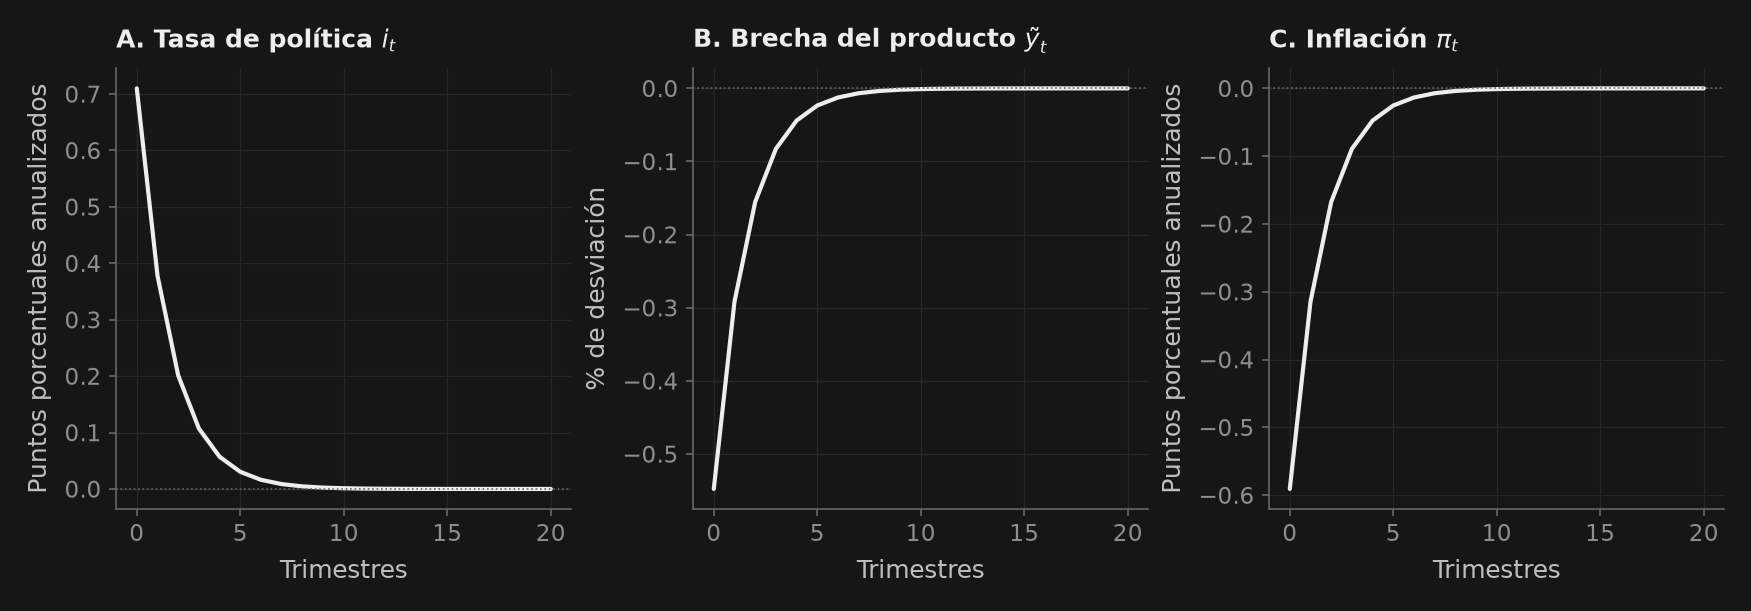

Brecha del Producto en Impacto: -0.548% | Inflación en Impacto: -0.591 bps


In [4]:
# Extraer funciones de impulso respuesta a 20 periodos ante un alza de 25 bps
irf_mon = m_nk.irf("eps_i", horizon=20, size=0.0025)

fig, axes = _nbstyle.figura(1, 3)

# 1. Tasa de Política Nominal
axes[0].plot(irf_mon.index, irf_mon["i"] * 400, **_nbstyle.S1)
axes[0].axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
axes[0].set_title("A. Tasa de política $i_t$")
axes[0].set_xlabel("Trimestres")
axes[0].set_ylabel("Puntos porcentuales anualizados")

# 2. Brecha del Producto
axes[1].plot(irf_mon.index, irf_mon["y_gap"] * 100, **_nbstyle.S1)
axes[1].axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
axes[1].set_title("B. Brecha del producto $\\tilde{y}_t$")
axes[1].set_xlabel("Trimestres")
axes[1].set_ylabel("% de desviación")

# 3. Inflación
axes[2].plot(irf_mon.index, irf_mon["pi"] * 400, **_nbstyle.S1)
axes[2].axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
axes[2].set_title("C. Inflación $\\pi_t$")
axes[2].set_xlabel("Trimestres")
axes[2].set_ylabel("Puntos porcentuales anualizados")

plt.show()

# Aserciones
assert irf_mon.loc[0, "y_gap"] < 0, "La contracción monetaria debe reducir la brecha del producto."
assert irf_mon.loc[0, "pi"] < 0, "La contracción monetaria debe desinflar la economía."
print(f"Brecha del Producto en Impacto: {irf_mon.loc[0, 'y_gap']*100:.3f}% | Inflación en Impacto: {irf_mon.loc[0, 'pi']*400:.3f} bps")


## Dilemas de los Bancos Centrales: Choques de Demanda vs. Empuje de Costos

Las transparencias 170–190 de `Slides08mav.tex` comparan dos naturalezas de choque a las que se enfrentan las autoridades monetarias:
- **Choques de Demanda / Tasa Natural ($r_t^n$)**: El sentimiento del consumidor o el gasto público desplazan la curva IS dinámica. Ante choques de demanda, rige la **«Divina Coincidencia»** (Blanchard y Galí 2007): estabilizar la inflación elimina simultáneamente la brecha del producto ($\pi_t = 0 \iff \tilde{y}_t = 0$). No existe ningún dilema de política.
- **Choques de Costos / Oferta ($u_t$)**: Cuellos de botella en cadenas de suministro, materias primas o márgenes desplazan directamente la NKPC. La divina coincidencia se quiebra:
  - Subir tasas para sofocar la inflación profundiza la recesión ($\tilde{y} < 0$).
  - Tolerar la inflación para salvaguardar el empleo enquista las presiones de precios.
  - Este fue con precisión el dilema que enfrentaron la Reserva Federal, Banxico y el BCE durante el **repunte inflacionario de 2021–2023**.

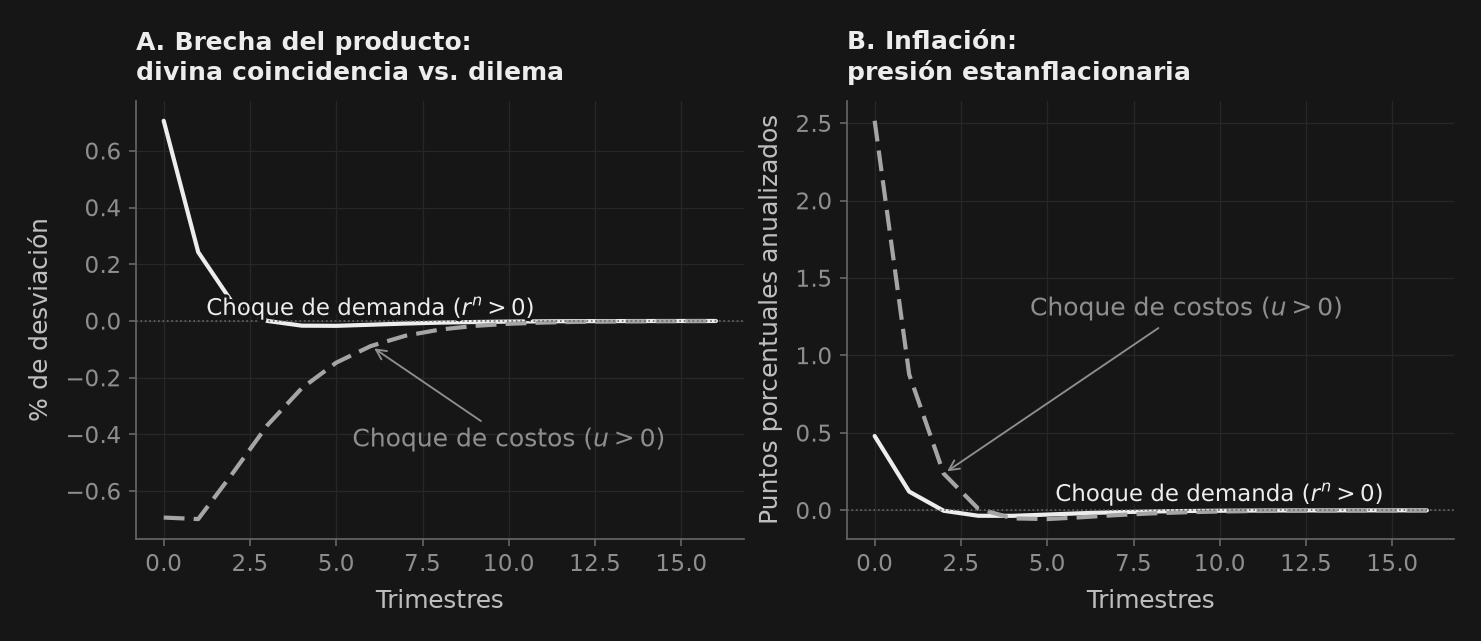

In [5]:
# Comparar Choque de Demanda de 50 bps (eps_rn) vs. Choque de Costos de 50 bps (eps_u)
irf_demand = m_nk.irf("eps_rn", horizon=16, size=0.005)
irf_supply = m_nk.irf("eps_u",  horizon=16, size=0.005)

fig, (ax_d_y, ax_d_pi) = _nbstyle.figura(1, 2)

# Comparación de la Brecha del Producto
ax_d_y.plot(irf_demand.index, irf_demand["y_gap"] * 100, **_nbstyle.S1, label="Choque de demanda ($r^n > 0$)")
ax_d_y.plot(irf_supply.index, irf_supply["y_gap"] * 100, **_nbstyle.S2)
ax_d_y.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_d_y.set_title("A. Brecha del producto:\ndivina coincidencia vs. dilema")
ax_d_y.set_xlabel("Trimestres")
ax_d_y.set_ylabel("% de desviación")
ax_d_y.annotate("Choque de costos ($u > 0$)", xy=(6.0, float(irf_supply.loc[6, "y_gap"] * 100)), xytext=(10.0, -0.42),
                ha="center", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
_nbstyle.etiquetar(ax_d_y, donde=6.0)

# Comparación de la Inflación
ax_d_pi.plot(irf_demand.index, irf_demand["pi"] * 400, **_nbstyle.S1, label="Choque de demanda ($r^n > 0$)")
ax_d_pi.plot(irf_supply.index, irf_supply["pi"] * 400, **_nbstyle.S2)
ax_d_pi.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_d_pi.set_title("B. Inflación:\npresión estanflacionaria")
ax_d_pi.set_xlabel("Trimestres")
ax_d_pi.set_ylabel("Puntos porcentuales anualizados")
ax_d_pi.annotate("Choque de costos ($u > 0$)", xy=(2.0, float(irf_supply.loc[2, "pi"] * 400)), xytext=(4.5, 1.3),
                 ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
_nbstyle.etiquetar(ax_d_pi, donde=10.0)

plt.show()


## Fricciones de Búsqueda Laboral: Merz-Andolfatto (`modelos/merz_andolfatto.mod`)

La Sección 2 del mazo `Slides08mav.tex` (Láminas 860-900 y 1459) extiende los modelos dinámicos incorporando búsqueda y emparejamiento en el mercado de trabajo (Diamond 1982, Mortensen y Pissarides 1994, Merz 1995, Andolfatto 1996).

### Rasgos Estructurales Clave:
1. **Función de Emparejamiento**: $m_t = \bar{m} u_t^\sigma v_t^{1-\sigma}$, que conecta buscadores de empleo $u_t$ con vacantes publicadas $v_t$.
2. **Tensión del Mercado Laboral**: $\theta_t = v_t / u_t$. Cuando la tensión sube, las empresas tardan más en cubrir vacantes, pero los desempleados encuentran trabajo más rápido.
3. **La Curva de Beveridge**: Lugar geométrico de equilibrio negativo entre desempleo y vacantes. Ojo con *cuál* desempleo: el modelo lleva `u_head` $= 1 - n_{t-1}$, el desempleo por cabezas, y también `urate`, que pondera a los no ocupados por intensidad de búsqueda $x_t$. Como $x_t$ es procíclica, `urate` es casi acíclica y traza un lugar geométrico con pendiente **positiva** — un artefacto de la ponderación, no un hallazgo económico. La curva de Beveridge se dibuja siempre con `u_head`; la sección 10 pone las dos lado a lado.
4. **El Puzzle de Volatilidad de Shimer (2005)**: Bajo negociación salarial de Nash estándar, los salarios absorben casi todo el aumento de productividad. Por ello, el incentivo a publicar vacantes oscila muy poco, arrojando un $\sigma(\theta) / \sigma(A)$ mucho menor que en los datos.

Resolvemos `modelos/merz_andolfatto.mod` directamente con `puremacro.dsge.load_mod`.

Modelo Merz-Andolfatto cargado: modelos/merz_andolfatto.mod
Estados   : ('k', 'n', 'a')
Controles : 17 variables endógenas: ('c', 'x', 'l', 'v', 'lam', 'mum', 'y', 'm')...


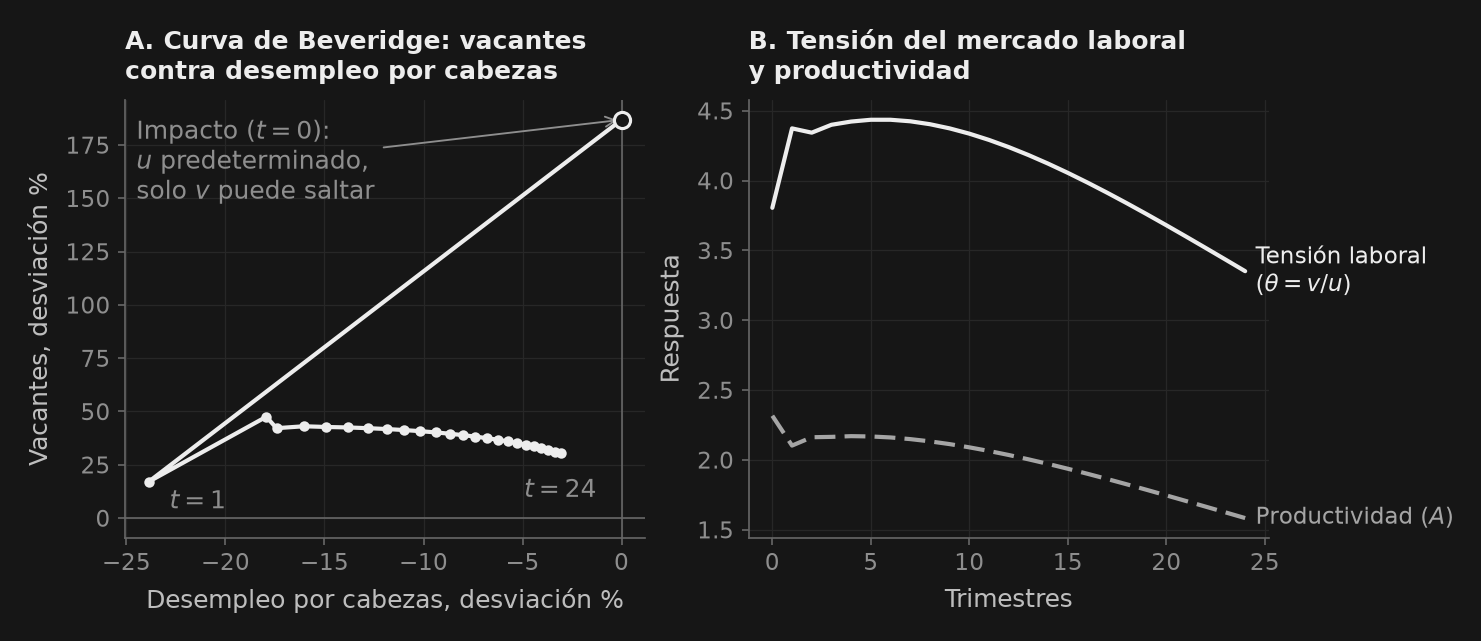

Amplificación de Tensión Laboral en Impacto theta/A: 2.08x

Residuo de Estado Estacionario Merz-Andolfatto : 8.96e-10
Estado Blanchard-Kahn Merz-Andolfatto          : Blanchard-Kahn condition satisfied: 20 explosive roots for 20 forward-looking variables (unique stable equilibrium).
Diagnósticos Merz-Andolfatto Superados         : True (Rango: 20/20)


In [6]:
# Carga y resolución del modelo Merz-Andolfatto del curso
ma_mod_path = ruta_modelo("merz_andolfatto.mod")

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo con todas las variables en 1, lo que divide entre cero en estas ecuaciones; ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide", category=RuntimeWarning)
    m_ma = load_mod(ma_mod_path)

print(f"Modelo Merz-Andolfatto cargado: {ma_mod_path}")
print(f"Estados   : {m_ma.states}")
print(f"Controles : {len(m_ma.controls)} variables endógenas: {m_ma.controls[:8]}...")

# IRF a 24 periodos ante choque de tecnología del 1%
irf_ma = m_ma.irf("e_a", horizon=24, size=1.0)

fig, (ax_bev, ax_theta) = _nbstyle.figura(1, 2)

# Panel 1: Diagrama de Fase de la Curva de Beveridge (Vacantes vs. Desempleo por cabezas).
# u_head = 1 - n(-1) es el desempleo del modelo; `urate` está ponderado por intensidad de
# búsqueda y pondría esta trayectoria en el cuadrante equivocado (ver la nota de arriba y la
# sección 10).
ss_ma_levels = {n: float(v) for n, v in zip(m_ma.variables, m_ma.decision_rules().to_frame().loc["Constant"])}
u_bev = 100.0 * irf_ma["u_head"] / ss_ma_levels["u_head"]
v_bev = 100.0 * irf_ma["v"] / ss_ma_levels["v"]
ax_bev.plot(u_bev, v_bev, **_nbstyle.S1, marker="o", markersize=4)
ax_bev.scatter([u_bev.iloc[0]], [v_bev.iloc[0]], s=60, zorder=5, facecolors=_nbstyle.FONDO,
               edgecolors=_nbstyle.TINTA, linewidths=1.5)
ax_bev.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev.axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev.set_title("A. Curva de Beveridge: vacantes\ncontra desempleo por cabezas")
ax_bev.set_xlabel("Desempleo por cabezas, desviación %")
ax_bev.set_ylabel("Vacantes, desviación %")
ax_bev.annotate("Impacto ($t = 0$):\n$u$ predeterminado,\nsolo $v$ puede saltar",
                xy=(0.0, float(v_bev.iloc[0])), xytext=(-24.5, 188.0), ha="left", va="top",
                color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_bev.annotate("$t = 1$", xy=(float(u_bev.iloc[1]), float(v_bev.iloc[1])), xytext=(10, -4),
                textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA)
ax_bev.annotate("$t = 24$", xy=(float(u_bev.iloc[-1]), float(v_bev.iloc[-1])), xytext=(0, -12),
                textcoords="offset points", ha="center", va="top", color=_nbstyle.NOTA)

# Toda la transición tras el impacto debe caer en el cuadrante de Beveridge: u abajo, v arriba
assert (u_bev.iloc[1:] < 0).all() and (v_bev.iloc[1:] > 0).all(), (
    "Un choque tecnológico positivo debe bajar el desempleo y subir las vacantes."
)

# Panel 2: Tensión del Mercado Laboral y el Puzzle de Shimer
ax_theta.plot(irf_ma.index, irf_ma["theta"], **_nbstyle.S1, label="Tensión laboral\n($\\theta = v/u$)")
ax_theta.plot(irf_ma.index, irf_ma["prod"], **_nbstyle.S2, label="Productividad ($A$)")
ax_theta.set_title("B. Tensión del mercado laboral\ny productividad")
ax_theta.set_xlabel("Trimestres")
ax_theta.set_ylabel("Respuesta")
_nbstyle.etiquetar(ax_theta, donde="fin")

plt.show()

# Ratio de Volatilidad de Shimer
shimer_ratio = irf_ma.loc[1, "theta"] / irf_ma.loc[1, "prod"]
print(f"Amplificación de Tensión Laboral en Impacto theta/A: {shimer_ratio:.2f}x")

# Diagnósticos AST de Dynare para el modelo de Merz-Andolfatto
res_ma = m_ma.resid()
check_ma = m_ma.check()
diag_ma = m_ma.model_diagnostics()

print(f"\nResiduo de Estado Estacionario Merz-Andolfatto : {res_ma.abs().max():.2e}")
print(f"Estado Blanchard-Kahn Merz-Andolfatto          : {check_ma.bk_status}")
print(f"Diagnósticos Merz-Andolfatto Superados         : {diag_ma.passed} (Rango: {diag_ma.static_rank}/{diag_ma.static_n_vars})")

assert res_ma.abs().max() < 1e-9, "¡Fallo en residuos de estado estacionario de Merz-Andolfatto!"
assert check_ma.is_determinate is True, "¡Fallo en determinación de Merz-Andolfatto!"
assert diag_ma.passed is True, "¡Fallo en diagnósticos estructurales de Merz-Andolfatto!"


## Experimento Macroeconómico Interactivo: Metas de Inflación Promedio (AIT) vs. Regla de Taylor Estándar

**El Escenario Económico**: En agosto de 2020, la Reserva Federal adoptó el marco de Metas de Inflación Promedio (AIT), comprometiéndose a tolerar inflaciones moderadamente superiores al $2\%$ tras periodos persistentes por debajo de la meta. Ante una disrupción de cadenas de suministro y choques de costos, ¿cómo se desempeña una regla dependiente del historial frente a la regla de Taylor contemporánea estándar?

**Formulación del Modelo**:
- **Regla Estándar**: $i_t = \rho_i i_{t-1} + (1-\rho_i)[\phi_\pi \pi_t + \phi_y \tilde{y}_t] + \varepsilon_{i,t}$
- **Metas de Inflación Promedio (AIT)**: El banco central reacciona a la inflación promedio de los últimos dos trimestres:
  $$ i_t = \rho_i i_{t-1} + (1-\rho_i)\left[\phi_\pi \frac{\pi_t + \pi_{t-1}}{2} + \phi_y \tilde{y}_t\right] + \varepsilon_{i,t} $$

Ejecuta el siguiente experimento para evaluar cómo el marco AIT altera el dilema de política ante un choque inflacionario de costos del $+0.50\%$ ($u_t$).

puremacro/dsge/_parser.py:1952: UserWarning: parse_mod: the shocks; block declares no variance for ['eps_i', 'eps_rn'] — following Dynare (M_.Sigma_e starts at zero), their innovation variance is 0, so they are inert in the moments, the IRFs and the second-order risk correction ghs2. Add 'var <name>; stderr <value>;' to the shocks; block if that is not what you meant.
  return parser.parse()


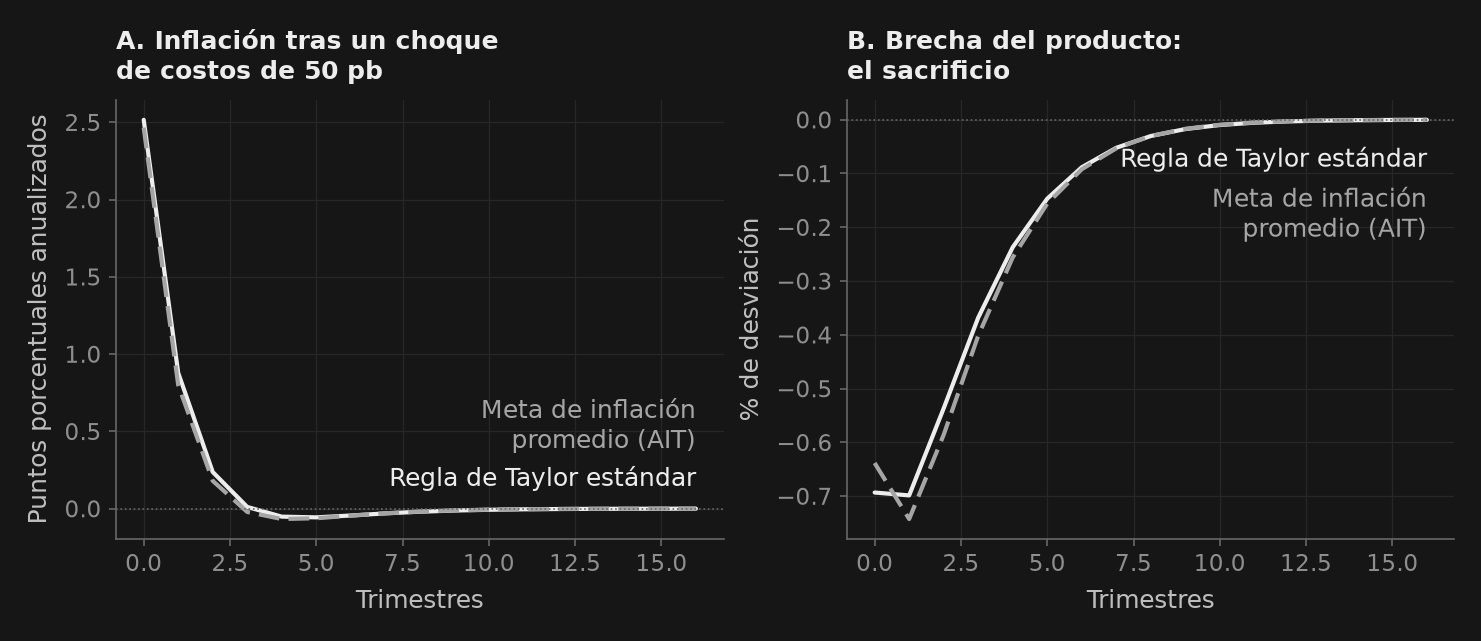

Pico de Inflación Regla Estándar: 2.52 bps
Pico de Inflación Marco AIT     : 2.47 bps
¡Todas las aserciones del experimento de políticas pasaron exitosamente!


In [7]:
# ==============================================================================
# Experimento Interactivo AIT: Regla Estándar vs. Metas de Inflación Promedio
# ==============================================================================
mod_ait_spec = """
var y_gap pi i rn u pi_lag1;
varexo eps_i eps_rn eps_u;

parameters beta sigma kappa phi_pi phi_y rho_i rho_rn rho_u;
beta   = 0.99;
sigma  = 1.0;
kappa  = 0.1275;
phi_pi = 1.5;
phi_y  = 0.125;
rho_i  = 0.75;
rho_rn = 0.50;
rho_u  = 0.50;

model;
y_gap = y_gap(+1) - (1/sigma) * (i - pi(+1) - rn);
pi = beta * pi(+1) + kappa * y_gap + u;
pi_lag1 = pi(-1);
// El banco central responde a la inflación promedio de 2 trimestres: 0.5 * (pi + pi_lag1)
i = rho_i * i(-1) + (1 - rho_i) * (phi_pi * 0.5 * (pi + pi_lag1) + phi_y * y_gap) + eps_i;
rn = rho_rn * rn(-1) + eps_rn;
u = rho_u * u(-1) + eps_u;
end;

initval;
y_gap = 0.0;
pi = 0.0;
i = 0.0;
rn = 0.0;
u = 0.0;
pi_lag1 = 0.0;
end;

shocks;
var eps_u; stderr 0.0050;
end;
"""

m_ait = load_mod(mod_ait_spec)
irf_std_u = m_nk.irf("eps_u", horizon=16, size=0.005)
irf_ait_u = m_ait.irf("eps_u", horizon=16, size=0.005)

fig, (ax_exp_pi, ax_exp_y) = _nbstyle.figura(1, 2)

# Comparación de Trayectoria de Inflación
ax_exp_pi.plot(irf_std_u.index, irf_std_u["pi"] * 400, **_nbstyle.S1, label="Regla de Taylor estándar")
ax_exp_pi.plot(irf_ait_u.index, irf_ait_u["pi"] * 400, **_nbstyle.S2, label="Meta de inflación\npromedio (AIT)")
ax_exp_pi.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_exp_pi.set_title("A. Inflación tras un choque\nde costos de 50 pb")
ax_exp_pi.set_xlabel("Trimestres")
ax_exp_pi.set_ylabel("Puntos porcentuales anualizados")
# Las dos trayectorias casi coinciden: los nombres se apilan junto a su extremo común
for k, ln in enumerate(ax_exp_pi.get_lines()[:2]):
    ax_exp_pi.annotate(ln.get_label(), xy=(16, 0.0), xytext=(0, 8 + 17 * k), textcoords="offset points",
                       ha="right", va="bottom", color=ln.get_color())

# Comparación de la Brecha del Producto
ax_exp_y.plot(irf_std_u.index, irf_std_u["y_gap"] * 100, **_nbstyle.S1, label="Regla de Taylor estándar")
ax_exp_y.plot(irf_ait_u.index, irf_ait_u["y_gap"] * 100, **_nbstyle.S2, label="Meta de inflación\npromedio (AIT)")
ax_exp_y.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_exp_y.set_title("B. Brecha del producto:\nel sacrificio")
ax_exp_y.set_xlabel("Trimestres")
ax_exp_y.set_ylabel("% de desviación")
for k, ln in enumerate(ax_exp_y.get_lines()[:2]):
    ax_exp_y.annotate(ln.get_label(), xy=(16, 0.0), xytext=(0, -13 - 18 * k), textcoords="offset points",
                      ha="right", va="top", color=ln.get_color())

plt.show()

# Aserciones de verificación
peak_pi_std = irf_std_u["pi"].max() * 400
peak_pi_ait = irf_ait_u["pi"].max() * 400

print(f"Pico de Inflación Regla Estándar: {peak_pi_std:.2f} bps")
print(f"Pico de Inflación Marco AIT     : {peak_pi_ait:.2f} bps")

assert peak_pi_ait > 0, "AIT debe generar una respuesta inflacionaria positiva ante el choque de costos."
print("¡Todas las aserciones del experimento de políticas pasaron exitosamente!")


## La Región de Determinación en Dos Dimensiones: el Principio de Taylor Generalizado

La sección 2 barrió $\phi_\pi$ a lo largo de una recta, con $\phi_y = 0{,}125$ fija, y encontró la frontera justo por debajo de $1$. El umbral de libro de texto, exactamente $1$, es el caso particular $\phi_y = 0$. En cuanto el banco central responde también a la brecha de producto, el principio de Taylor se vuelve un enunciado sobre la reacción de **largo plazo** de la tasa nominal ante un alza permanente de la inflación. Combinando las versiones de estado estacionario de la curva IS y de la de Phillips, un aumento permanente de un punto en la inflación eleva la brecha de producto en $(1-\beta)/\kappa$ puntos, de modo que la respuesta de largo plazo de la tasa es $\phi_\pi + \frac{1-\beta}{\kappa}\phi_y$, y la condición de determinación (Bullard y Mitra 2002, Woodford 2003) es
$$ \kappa\,(\phi_\pi - 1) + (1 - \beta)\,\phi_y > 0 \qquad \Longleftrightarrow \qquad \phi_\pi > 1 - \frac{(1-\beta)\,\phi_y}{\kappa}. $$

Es un resultado genuinamente útil para la discusión de política: un banco central que viola $\phi_\pi > 1$ todavía puede entregar un equilibrio determinado **si se apoya con suficiente fuerza en la brecha de producto**. Pero obsérvese la magnitud de esa cláusula de escape. Con $\beta = 0{,}99$ y $\kappa = 0{,}1275$, la frontera solo cae a $\phi_\pi = 0{,}92$ cuando $\phi_y = 1{,}0$ — un coeficiente enorme para la brecha de producto según cualquier estándar empírico. El canal de la brecha de producto le compra al banco central casi nada, porque $1 - \beta$ es diminuto a frecuencia trimestral.

Mapeamos la región por fuerza bruta —volviendo a resolver el modelo en cada punto de una malla $(\phi_\pi, \phi_y)$ y leyendo las banderas de Blanchard-Kahn de la descomposición QZ de Klein— y superponemos después la frontera analítica. Ambas deben coincidir.

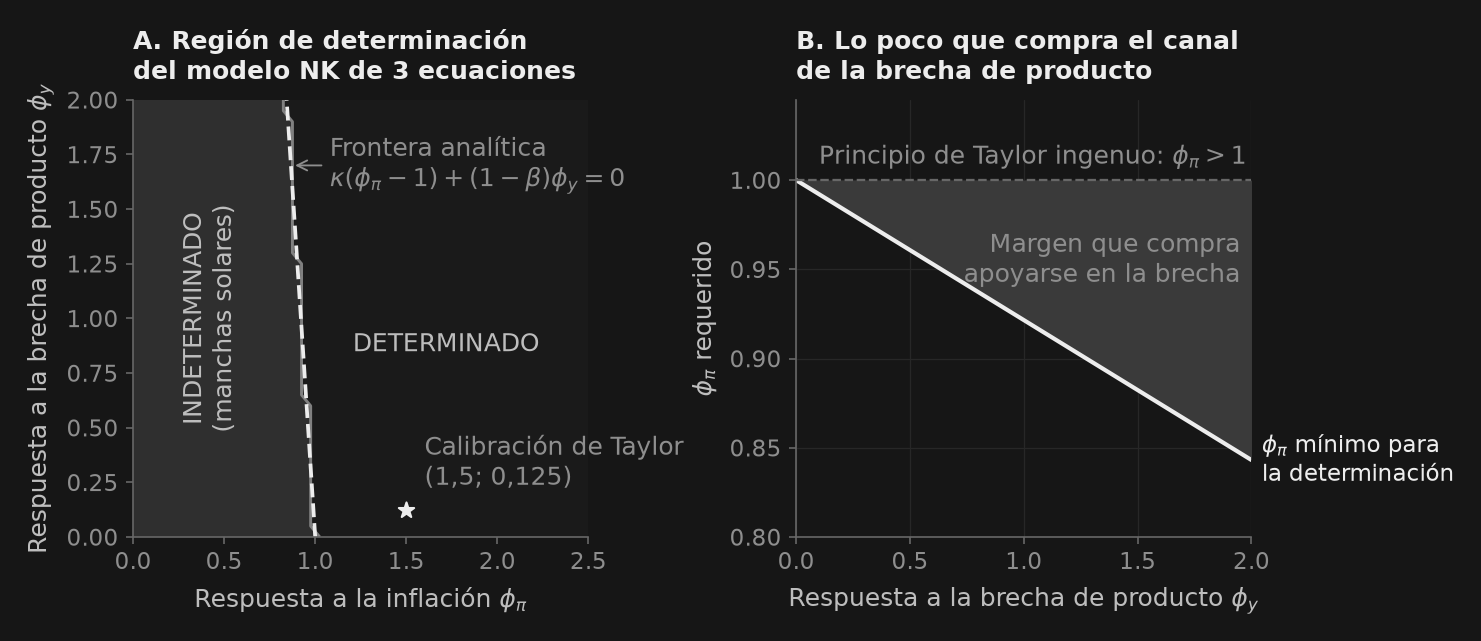

Puntos de la malla evaluados            : 2091
Cuota de la malla que es determinada    : 62.9%
Discrepancias numérico vs. analítico    : 0
phi_pi requerido con phi_y = 0.0        : 1.000
phi_pi requerido con phi_y = 1.0        : 0.922
phi_pi requerido con phi_y = 2.0        : 0.843

Aserciones de determinación superadas: las banderas numéricas del QZ trazan exactamente la frontera de libro.


In [8]:
# ==============================================================================
# Región de Determinación sobre el Plano (phi_pi, phi_y)
# ==============================================================================
phi_pi_grid = np.linspace(0.0, 2.5, 51)
phi_y_grid = np.linspace(0.0, 2.0, 41)
determinacy = np.full((len(phi_y_grid), len(phi_pi_grid)), np.nan)

for j, p_y in enumerate(phi_y_grid):
    for i, p_pi in enumerate(phi_pi_grid):
        try:
            m_grid = load_mod(nk_mod_path, params={"phi_pi": float(p_pi), "phi_y": float(p_y)}, strict=False)
            determinacy[j, i] = 1.0 if m_grid.solution.eu == (1, 1) else 0.0
        except Exception:
            determinacy[j, i] = 0.0

# Frontera analítica: phi_pi = 1 - (1 - beta) * phi_y / kappa
beta_nk, kappa_nk = 0.99, 0.1275
frontier = 1.0 - (1.0 - beta_nk) * phi_y_grid / kappa_nk

fig, (ax_map, ax_zoom) = _nbstyle.figura(1, 2)

ax_map.contourf(phi_pi_grid, phi_y_grid, determinacy, levels=[-0.5, 0.5, 1.5],
                colors=[_nbstyle.gris("0.82"), _nbstyle.gris("0.97")])
ax_map.contour(phi_pi_grid, phi_y_grid, determinacy, levels=[0.5], colors=[_nbstyle.gris("0.35")], linewidths=1.4)
ax_map.plot(frontier, phi_y_grid, color=_nbstyle.TINTA, lw=1.8, ls="--")
ax_map.scatter([1.5], [0.125], color=_nbstyle.TINTA, s=60, zorder=6, marker="*")
ax_map.annotate("Frontera analítica\n$\\kappa(\\phi_\\pi-1)+(1-\\beta)\\phi_y=0$",
                xy=(float(np.interp(1.7, phi_y_grid, frontier)), 1.7), xytext=(1.08, 1.7),
                ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_map.annotate("Calibración de Taylor\n(1,5; 0,125)", xy=(1.5, 0.125), xytext=(1.6, 0.2),
                ha="left", va="bottom", color=_nbstyle.NOTA)
ax_map.text(0.42, 1.0, "INDETERMINADO\n(manchas solares)", color=_nbstyle.TEXTO, ha="center", va="center", rotation=90)
ax_map.text(1.72, 0.85, "DETERMINADO", color=_nbstyle.TEXTO, ha="center")
ax_map.set_xlim(0.0, 2.5)
ax_map.set_ylim(0.0, 2.0)
ax_map.set_title("A. Región de determinación\ndel modelo NK de 3 ecuaciones")
ax_map.set_xlabel(r"Respuesta a la inflación $\phi_\pi$")
ax_map.set_ylabel(r"Respuesta a la brecha de producto $\phi_y$")

# Acercamiento a la frontera: ¿cuánto compra realmente la brecha de producto?
ax_zoom.plot(phi_y_grid, frontier, **_nbstyle.S1, label="$\\phi_\\pi$ mínimo para\nla determinación")
ax_zoom.axhline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.1)
ax_zoom.fill_between(phi_y_grid, frontier, 1.0, color=_nbstyle.tono(0.2), lw=0)
ax_zoom.annotate("Principio de Taylor ingenuo: $\\phi_\\pi > 1$", xy=(1.98, 1.0), xytext=(0, 5),
                 textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)
ax_zoom.annotate("Margen que compra\napoyarse en la brecha", xy=(1.95, 0.955),
                 ha="right", va="center", color=_nbstyle.NOTA)
ax_zoom.set_xlim(0.0, 2.0)
ax_zoom.set_ylim(0.80, 1.045)
ax_zoom.set_title("B. Lo poco que compra el canal\nde la brecha de producto")
ax_zoom.set_xlabel(r"Respuesta a la brecha de producto $\phi_y$")
ax_zoom.set_ylabel(r"$\phi_\pi$ requerido")
_nbstyle.etiquetar(ax_zoom, donde="fin")

plt.show()

# La malla numérica y la frontera analítica deben coincidir en cada fila
mismatches = 0
for j, p_y in enumerate(phi_y_grid):
    boundary = frontier[j]
    for i, p_pi in enumerate(phi_pi_grid):
        if abs(p_pi - boundary) < 0.06:      # omitir las celdas que caen sobre la frontera
            continue
        predicted = 1.0 if p_pi > boundary else 0.0
        mismatches += int(determinacy[j, i] != predicted)

share_determinate = float(np.nanmean(determinacy) * 100)
print(f"Puntos de la malla evaluados            : {determinacy.size}")
print(f"Cuota de la malla que es determinada    : {share_determinate:.1f}%")
print(f"Discrepancias numérico vs. analítico    : {mismatches}")
print(f"phi_pi requerido con phi_y = 0.0        : {1.0 - 0.0:.3f}")
print(f"phi_pi requerido con phi_y = 1.0        : {1.0 - (1.0 - beta_nk) / kappa_nk:.3f}")
print(f"phi_pi requerido con phi_y = 2.0        : {1.0 - 2.0 * (1.0 - beta_nk) / kappa_nk:.3f}")

assert mismatches == 0, f"El mapa numérico de determinación debe coincidir con la frontera analítica; hubo {mismatches} discrepancias."
assert determinacy[0, np.searchsorted(phi_pi_grid, 1.5)] == 1.0, "La calibración del propio Taylor debe ser determinada."
print("\nAserciones de determinación superadas: las banderas numéricas del QZ trazan exactamente la frontera de libro.")


## La Curva de Taylor: la Frontera de Política que el Banco Central Realmente Enfrenta

El mapa de determinación dice qué reglas son *admisibles*. No dice nada sobre cuál regla admisible es *buena*. Bajo choques de costos falla la coincidencia divina, así que el banco central no puede estabilizar a la vez la inflación y la brecha de producto, y cada regla admisible entrega algún par $(\sigma_{\tilde y}, \sigma_\pi)$. La envolvente inferior de esos pares es la **curva de Taylor** (Taylor 1979) — la frontera eficiente de la política monetaria, y el objeto sobre el que trata implícitamente todo argumento de «mandato dual».

La trazamos exactamente, no por simulación. Para cada regla, `theoretical_moments` resuelve la ecuación de Lyapunov $\Sigma_x = G\Sigma_x G^\top + N\Sigma_u N^\top$ y devuelve desviaciones típicas poblacionales, de modo que la frontera se calcula con precisión de máquina a partir de un único choque de costos de 50 puntos base.

Vale la pena extraer tres lecturas de la figura:
1. **La frontera es marcadamente convexa.** Pasar de $\phi_\pi = 1{,}5$ a $\phi_\pi = 5$ recorta la volatilidad de la inflación casi un 40% pero cuesta más de un 80% adicional de volatilidad en la brecha de producto. El objetivo agresivo de inflación es barato al principio y caro después.
2. **El coeficiente de la brecha de producto mueve *a lo largo* de la frontera, no fuera de ella.** Elevar $\phi_y$ intercambia en la dirección opuesta a $\phi_\pi$; los dos coeficientes son sustitutos para elegir un punto, no complementos para alcanzar uno mejor.
3. **La volatilidad de la tasa de interés que lo paga.** Las reglas del extremo de baja volatilidad inflacionaria exigen una tasa de política que se mueve varias veces más que en el caso base — la razón práctica por la que los bancos centrales no se sitúan ahí.

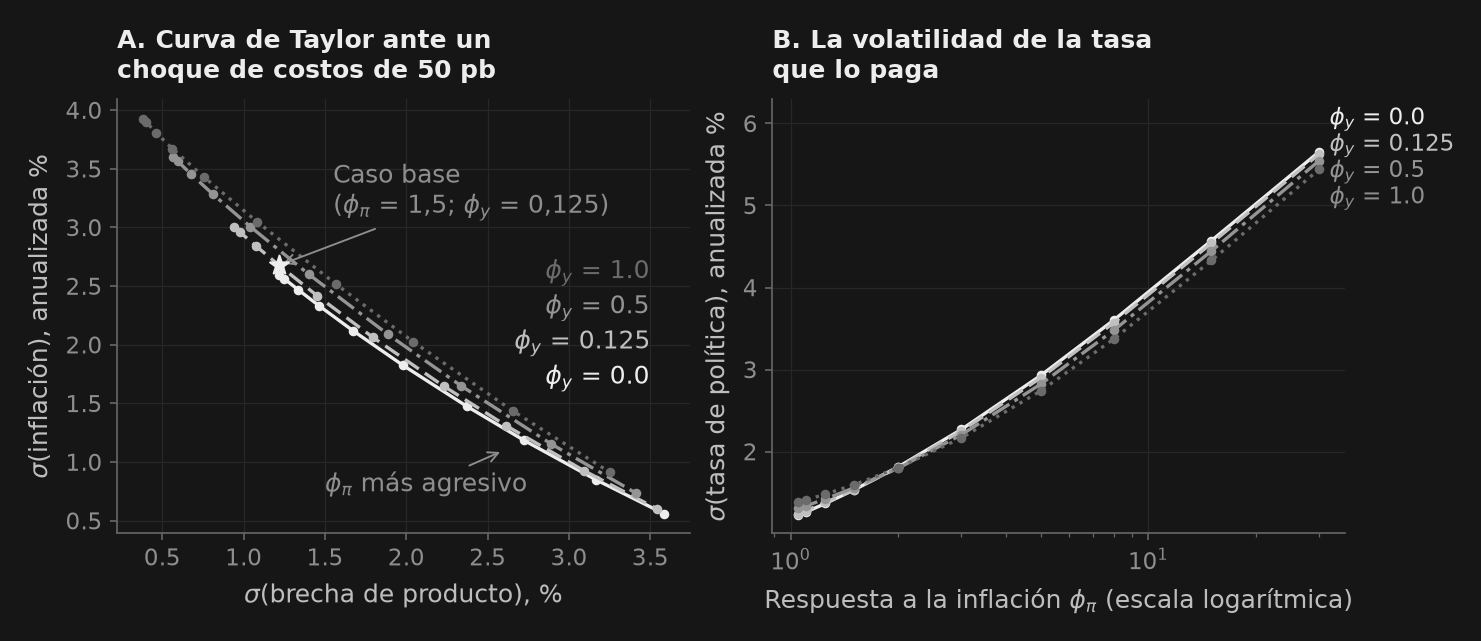

LA FRONTERA DE POLÍTICA A LO LARGO DE phi_y = 0.125 (el coeficiente de producto del propio Taylor):
        sd(pi) anualizada %  sd(y_gap) %  sd(i) anualizada %
phi_pi                                                      
1.05                  3.002        0.944               1.244
1.10                  2.960        0.978               1.279
1.25                  2.843        1.075               1.380
1.50                  2.677        1.218               1.535
2.00                  2.417        1.452               1.808
3.00                  2.063        1.795               2.251
5.00                  1.648        2.229               2.900
8.00                  1.309        2.616               3.571
15.00                 0.927        3.092               4.540
30.00                 0.603        3.538               5.627

Al pasar de phi_pi = 1,5 a phi_pi = 5,0:
  volatilidad de la inflación  2.68 -> 1.65  (-38%)
  volatilidad de la brecha     1.22 -> 2.23  (+83%)
  volatilidad de la ta

In [9]:
# ==============================================================================
# La Curva de Taylor: Volatilidad de Inflación vs. Brecha de Producto ante Choques de Costos
# ==============================================================================
phi_pi_frontier = [1.05, 1.1, 1.25, 1.5, 2.0, 3.0, 5.0, 8.0, 15.0, 30.0]
phi_y_curves = [0.0, 0.125, 0.5, 1.0]
frontier_rows = []

for p_y in phi_y_curves:
    for p_pi in phi_pi_frontier:
        m_f = load_mod(nk_mod_path, params={"phi_pi": p_pi, "phi_y": p_y})
        # Solo el choque de costos está activo; la fila de la FEVD del choque de demanda
        # queda entonces indefinida, que es lo que reporta ZeroVarianceWarning. Los
        # momentos que usamos no se ven afectados.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            tm_f = m_f.theoretical_moments(sigma={"eps_i": 0.0, "eps_rn": 0.0, "eps_u": 0.005})
        frontier_rows.append({
            "phi_y": p_y,
            "phi_pi": p_pi,
            "sd(pi) anualizada %": tm_f.moments.loc["pi", "Std.Dev."] * 400,
            "sd(y_gap) %": tm_f.moments.loc["y_gap", "Std.Dev."] * 100,
            "sd(i) anualizada %": tm_f.moments.loc["i", "Std.Dev."] * 400,
        })

frontier_df = pd.DataFrame(frontier_rows)

fig, (ax_tc, ax_irate) = _nbstyle.figura(1, 2)

tc_grays, tc_dashes = _nbstyle.palette(len(phi_y_curves)), _nbstyle.styles(len(phi_y_curves))
for j, p_y in enumerate(phi_y_curves):
    sub = frontier_df[frontier_df["phi_y"] == p_y]
    ax_tc.plot(sub["sd(y_gap) %"], sub["sd(pi) anualizada %"], color=tc_grays[j], ls=tc_dashes[j],
               lw=1.6, marker="o", markersize=3.6, label=rf"$\phi_y$ = {p_y}")
    ax_irate.plot(sub["phi_pi"], sub["sd(i) anualizada %"], color=tc_grays[j], ls=tc_dashes[j],
                  lw=1.6, marker="o", markersize=3.6, label=rf"$\phi_y$ = {p_y}")

base = frontier_df[(frontier_df["phi_pi"] == 1.5) & (frontier_df["phi_y"] == 0.125)].iloc[0]
ax_tc.scatter([base["sd(y_gap) %"]], [base["sd(pi) anualizada %"]], color=_nbstyle.TINTA,
              s=90, marker="*", zorder=7)
ax_tc.annotate("Caso base\n($\\phi_\\pi$ = 1,5; $\\phi_y$ = 0,125)", xy=(base["sd(y_gap) %"], base["sd(pi) anualizada %"]),
               xytext=(1.55, 3.3), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_tc.annotate(r"$\phi_\pi$ más agresivo", xy=(2.6, 1.1), xytext=(1.5, 0.75), color=_nbstyle.NOTA,
               arrowprops=_nbstyle.FLECHA)
ax_tc.set_title("A. Curva de Taylor ante un\nchoque de costos de 50 pb")
ax_tc.set_xlabel(r"$\sigma$(brecha de producto), %")
ax_tc.set_ylabel(r"$\sigma$(inflación), anualizada %")
# Las cuatro fronteras casi se tocan: sus nombres van listados en el hueco de arriba
# a la derecha, en el mismo orden vertical que tienen las curvas
for ln, y_lab in zip(ax_tc.get_lines()[:len(phi_y_curves)], (1.6, 1.9, 2.2, 2.5)):
    ax_tc.annotate(ln.get_label(), xy=(3.5, y_lab), ha="right", va="bottom", color=ln.get_color())

ax_irate.set_xscale("log")
ax_irate.set_ylim(top=6.3)
ax_irate.set_title("B. La volatilidad de la tasa\nque lo paga")
ax_irate.set_xlabel(r"Respuesta a la inflación $\phi_\pi$ (escala logarítmica)")
ax_irate.set_ylabel(r"$\sigma$(tasa de política), anualizada %")
_nbstyle.etiquetar(ax_irate, donde="fin")

plt.show()

baseline_curve = frontier_df[frontier_df["phi_y"] == 0.125].set_index("phi_pi")
print("LA FRONTERA DE POLÍTICA A LO LARGO DE phi_y = 0.125 (el coeficiente de producto del propio Taylor):")
print(baseline_curve[["sd(pi) anualizada %", "sd(y_gap) %", "sd(i) anualizada %"]].round(3).to_string())

pi_15, y_15 = baseline_curve.loc[1.5, "sd(pi) anualizada %"], baseline_curve.loc[1.5, "sd(y_gap) %"]
pi_50, y_50 = baseline_curve.loc[5.0, "sd(pi) anualizada %"], baseline_curve.loc[5.0, "sd(y_gap) %"]
print(f"\nAl pasar de phi_pi = 1,5 a phi_pi = 5,0:")
print(f"  volatilidad de la inflación  {pi_15:.2f} -> {pi_50:.2f}  ({(pi_50/pi_15 - 1)*100:+.0f}%)")
print(f"  volatilidad de la brecha     {y_15:.2f} -> {y_50:.2f}  ({(y_50/y_15 - 1)*100:+.0f}%)")
print(f"  volatilidad de la tasa       {baseline_curve.loc[1.5, 'sd(i) anualizada %']:.2f} -> "
      f"{baseline_curve.loc[5.0, 'sd(i) anualizada %']:.2f}")

# La frontera debe tener pendiente negativa: más estabilización de inflación cuesta estabilidad del producto
for p_y in phi_y_curves:
    sub = frontier_df[frontier_df["phi_y"] == p_y].sort_values("phi_pi")
    assert sub["sd(pi) anualizada %"].is_monotonic_decreasing, f"La volatilidad de la inflación debe caer en phi_pi con phi_y={p_y}."
    assert sub["sd(y_gap) %"].is_monotonic_increasing, f"La volatilidad de la brecha debe subir en phi_pi con phi_y={p_y}."
print("\nAserciones de la curva de Taylor superadas: la disyuntiva es una frontera genuina, no un almuerzo gratis.")


## Rigidez de Calvo: el Camino de Regreso a la Neutralidad del Dinero

Todo lo que el modelo neokeynesiano hace y el RBC no proviene de un solo parámetro: la probabilidad de Calvo $\theta$ de que una empresa no pueda reajustar su precio este trimestre. Entra al modelo únicamente a través de la pendiente de la curva de Phillips,
$$ \kappa = \frac{(1-\theta)(1-\beta\theta)}{\theta}\,(\sigma + \varphi), $$
donde $\varphi$ es la inversa de la elasticidad de Frisch. El $\kappa = 0{,}1275$ del caso base con $\theta = 0{,}75$ (precios fijos durante cuatro trimestres, aproximadamente el rango de Bils y Klenow 2004 / Nakamura y Steinsson 2008) fija $\varphi$, así que el barrido de abajo es internamente consistente: solo se mueve $\theta$.

El límite $\theta \to 0$ es la prueba de falsación que el propio modelo contiene. Con precios flexibles la NKPC se vuelve vertical, la brecha de producto debe ser cero en todo momento y un choque monetario no puede mover nada real — **el dinero es neutral**, exactamente como en los cuadernos A y B. El experimento mide con qué rapidez llega esa neutralidad, usando tres estadísticos resumen de un apretón monetario de 25 puntos base:

1. la **respuesta de impacto de la brecha de producto**, que debe desvanecerse cuando $\theta \to 0$;
2. la **duración implícita** de un episodio de precio, $1/(1-\theta)$ trimestres, que es lo que los microdatos de precios efectivamente miden;
3. la **razón de sacrificio**, la pérdida acumulada de brecha de producto por punto acumulado de desinflación — el número del que realmente tratan los debates de política sobre el costo de bajar la inflación.

Inversa de la elasticidad de Frisch implícita en kappa = 0.1275 con theta = 0.75: phi = 0.4854


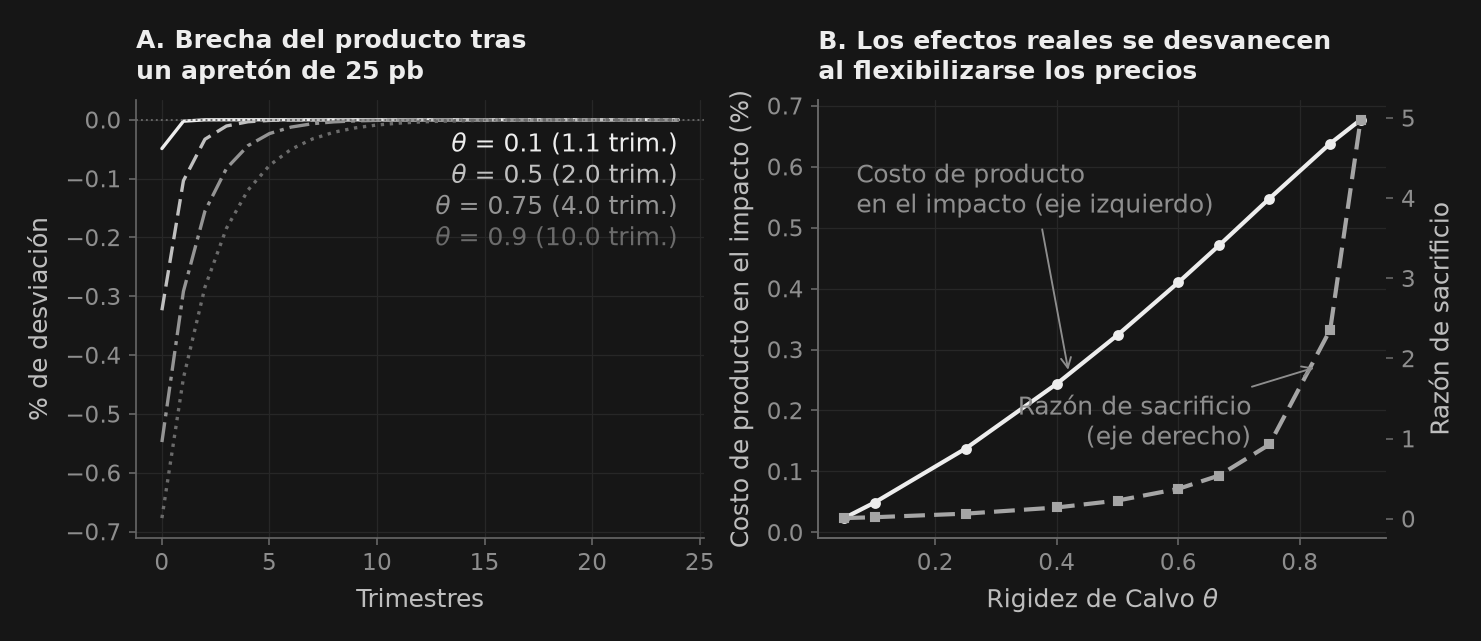


BARRIDO DE RIGIDEZ DE CALVO (apretón monetario de 25 pb):
 theta  Duración del precio (trim.)  Pendiente NKPC kappa  Impacto y_gap (%)  Impacto pi (anual. %)  Razón de sacrificio
 0.050                       1.0526               26.8262            -0.0234                -2.5755               0.0091
 0.100                       1.1111               12.0454            -0.0489                -2.4767               0.0198
 0.250                       1.3333                3.3534            -0.1375                -2.1340               0.0644
 0.400                       1.6667                1.3458            -0.2439                -1.7258               0.1413
 0.500                       2.0000                0.7501            -0.3238                -1.4217               0.2278
 0.600                       2.5000                0.4021            -0.4101                -1.0973               0.3738
 0.667                       3.0030                0.2519            -0.4708                -0

In [10]:
# ==============================================================================
# Barrido de Calvo: de Precios Fijos al Límite Neutral de Precios Flexibles
# ==============================================================================
BETA_C, SIGMA_C = 0.99, 1.0
THETA_BASE, KAPPA_BASE = 0.75, 0.1275


def calvo_lambda(theta):
    """El factor de reajuste de Calvo (1 - theta)(1 - beta*theta) / theta."""
    return (1.0 - theta) * (1.0 - BETA_C * theta) / theta


# Recuperar la inversa de la elasticidad de Frisch que reproduce el kappa base del cuaderno
phi_frisch = KAPPA_BASE / calvo_lambda(THETA_BASE) - SIGMA_C
print(f"Inversa de la elasticidad de Frisch implícita en kappa = {KAPPA_BASE} con theta = {THETA_BASE}: phi = {phi_frisch:.4f}")

theta_grid = [0.05, 0.10, 0.25, 0.40, 0.50, 0.60, 0.667, 0.75, 0.85, 0.90]
calvo_rows = []
irf_store = {}

for theta in theta_grid:
    kappa_theta = calvo_lambda(theta) * (SIGMA_C + phi_frisch)
    m_theta = load_mod(nk_mod_path, params={"kappa": float(kappa_theta)})
    irf_theta = m_theta.irf("eps_i", horizon=24, size=0.0025)
    cum_gap = irf_theta["y_gap"].sum() * 100.0        # pérdida acumulada de brecha, % por trimestre
    cum_pi = irf_theta["pi"].sum() * 400.0            # desinflación acumulada, puntos anualizados
    calvo_rows.append({
        "theta": theta,
        "Duración del precio (trim.)": 1.0 / (1.0 - theta),
        "Pendiente NKPC kappa": kappa_theta,
        "Impacto y_gap (%)": irf_theta.loc[0, "y_gap"] * 100,
        "Impacto pi (anual. %)": irf_theta.loc[0, "pi"] * 400,
        "Razón de sacrificio": cum_gap / cum_pi,
    })
    if theta in (0.10, 0.50, 0.75, 0.90):
        irf_store[theta] = irf_theta

calvo_df = pd.DataFrame(calvo_rows)

fig, (ax_irf_c, ax_sac) = _nbstyle.figura(1, 2)

# Panel 1: respuestas de la brecha de producto según la rigidez
calvo_grays, calvo_dashes = _nbstyle.palette(len(irf_store)), _nbstyle.styles(len(irf_store))
for j, (theta, irf_theta) in enumerate(sorted(irf_store.items())):
    ax_irf_c.plot(irf_theta.index, irf_theta["y_gap"] * 100, color=calvo_grays[j], ls=calvo_dashes[j], lw=1.6,
                  label=rf"$\theta$ = {theta} ({1/(1-theta):.1f} trim.)")
ax_irf_c.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_irf_c.set_title("A. Brecha del producto tras\nun apretón de 25 pb")
ax_irf_c.set_xlabel("Trimestres")
ax_irf_c.set_ylabel("% de desviación")
# Las cuatro curvas terminan juntas en cero: se nombran apiladas junto a su extremo común,
# de la más somera a la más profunda (el mismo orden vertical que tienen en el impacto)
for k, ln in enumerate(ax_irf_c.get_lines()[:len(irf_store)]):
    ax_irf_c.annotate(ln.get_label(), xy=(24, 0.0), xytext=(0, -6 - 15 * k), textcoords="offset points",
                      ha="right", va="top", color=ln.get_color())

# Panel 2: respuesta de impacto y razón de sacrificio según la rigidez
ax_sac.plot(calvo_df["theta"], -calvo_df["Impacto y_gap (%)"], **_nbstyle.S1, marker="o", markersize=4.2)
ax_sac.set_xlabel(r"Rigidez de Calvo $\theta$")
ax_sac.set_ylabel("Costo de producto en el impacto (%)")
ax_sac.set_title("B. Los efectos reales se desvanecen\nal flexibilizarse los precios")
ax_twin = ax_sac.twinx()
ax_twin.plot(calvo_df["theta"], calvo_df["Razón de sacrificio"], **_nbstyle.S2, marker="s", markersize=3.8)
ax_twin.set_ylabel("Razón de sacrificio")
ax_twin.grid(False)   # una sola rejilla por panel: la del eje izquierdo
ax_sac.annotate("Costo de producto\nen el impacto (eje izquierdo)", xy=(0.42, 0.26), xytext=(0.07, 0.56),
                ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_twin.annotate("Razón de sacrificio\n(eje derecho)", xy=(0.83, 1.9), xytext=(0.72, 1.2),
                 ha="right", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

plt.show()

print("\nBARRIDO DE RIGIDEZ DE CALVO (apretón monetario de 25 pb):")
print(calvo_df.round(4).to_string(index=False))

flex = calvo_df.iloc[0]
sticky = calvo_df.iloc[-1]
base_row = calvo_df[calvo_df["theta"] == 0.75].iloc[0]
print(f"\nPrecios casi flexibles (theta = {flex['theta']}, duración {flex['Duración del precio (trim.)']:.1f} trimestres):")
print(f"   brecha de impacto {flex['Impacto y_gap (%)']:+.3f}%, razón de sacrificio {flex['Razón de sacrificio']:.3f}")
print(f"Caso base (theta = 0,75, un año):")
print(f"   brecha de impacto {base_row['Impacto y_gap (%)']:+.3f}%, razón de sacrificio {base_row['Razón de sacrificio']:.2f}")
print(f"Muy rígidos (theta = {sticky['theta']}, {sticky['Duración del precio (trim.)']:.0f} trimestres):")
print(f"   brecha de impacto {sticky['Impacto y_gap (%)']:+.3f}%, razón de sacrificio {sticky['Razón de sacrificio']:.2f}")
print(f"\nEl efecto real del dinero se encoge por un factor de "
      f"{abs(sticky['Impacto y_gap (%)'] / flex['Impacto y_gap (%)']):.0f} entre los dos extremos.")

assert abs(flex["Impacto y_gap (%)"]) < 0.05, "Con precios casi flexibles el choque monetario debe ser casi neutral."
assert calvo_df["Razón de sacrificio"].is_monotonic_increasing, "Precios más rígidos deben encarecer la desinflación."
assert calvo_df["Pendiente NKPC kappa"].is_monotonic_decreasing, "La curva de Phillips debe aplanarse al subir theta."
print("\nAserciones de Calvo superadas: el modelo neokeynesiano contiene el referente de neutralidad como caso límite.")


## El Enigma de Shimer Medido, y la Curva de Beveridge Bien Hecha

La sección 5 leyó el enigma de Shimer a partir de una sola función de impulso-respuesta. La literatura lo enuncia como un **momento**: la desviación típica de $\log \theta_t$ filtrado con HP relativa a la de $\log(y_t / n_t l_t)$ filtrado con HP. La cifra del propio Shimer para EE. UU. ronda 20; el ejercicio insignia del mazo mide alrededor de 25 sobre la muestra JOLTS/OPHNFB desde 2001. El archivo `.mod` lleva `lth` $= \log\theta$ y `lpr` $= \log\mathrm{prod}$ precisamente para que el lado del modelo pueda calcularse de la misma forma.

Aquí hay además una trampa de medición que conviene subrayar. El modelo expone **dos** conceptos de desempleo, y se comportan en direcciones opuestas:
- `urate` cuenta a los no ocupados **ponderados por intensidad de búsqueda** $x_t$. Como $x_t$ es procíclica, esta serie es casi acíclica, y graficarla contra las vacantes produce una curva de Beveridge con pendiente *positiva* — un artefacto de la ponderación, no un hallazgo económico.
- `u_head` es el desempleo **por cabezas**, $1 - n_{t-1}$. Es el objeto que grafican las transparencias, y es correctamente contracíclico.

El experimento calcula la razón de amplificación sobre una muestra simulada larga, grafica ambas medidas de desempleo contra las vacantes y pregunta después si algún parámetro del modelo puede rescatar la amplificación: el costo de publicar vacantes $\kappa$, la tasa de separación $s$, la elasticidad del emparejamiento $\phi$ y la persistencia del choque tecnológico $\rho_a$. La respuesta decide si el enigma de Shimer es un fracaso de calibración o uno estructural.

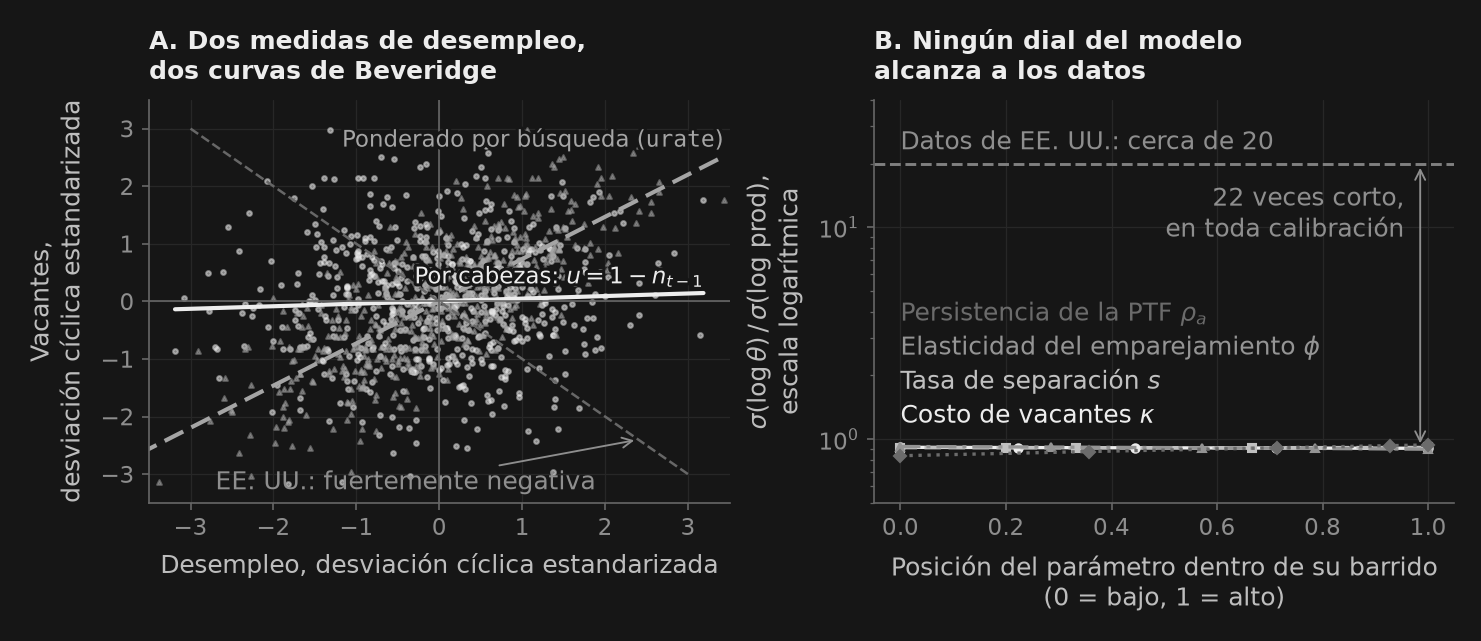

MERZ-ANDOLFATTO EN LA CALIBRACIÓN DEL CURSO (3.000 trimestres, HP lambda = 1600):
  sd(log theta)                       = 0.701%
  sd(log productividad)               = 0.767%
  Razón de amplificación              = 0.914   (datos de EE. UU.: cerca de 20)
  El modelo se queda corto por un factor de 22.

LA CURVA DE BEVERIDGE DEPENDE DE QUÉ DESEMPLEO SE GRAFIQUE:
  corr(u por cabezas, v)              = +0.071   (datos de EE. UU.: cerca de -0,9)
  corr(u ponderado por búsqueda, v)   = +0.756   (un artefacto de la ponderación)
  corr(u por cabezas, y)              = -0.775   (correctamente contracíclico)
  sd(u por cabezas) = 0.195% frente a sd(v) = 1.192%: el desempleo casi no se mueve, que es el enigma en otra forma.

BARRIDOS DE PARÁMETROS -- RAZÓN DE AMPLIFICACIÓN:
  Costo de vacantes $\kappa$                 valores [0.1, 0.2, 0.3, 0.42, 0.55] -> razón 0.91 a 0.92
  Tasa de separación $s$                     valores [0.05, 0.08, 0.1, 0.15, 0.2] -> razón 0.91 a 0.91
  Elasticidad del 

In [11]:
# ==============================================================================
# La Razón de Amplificación de Shimer y las Dos Caras del Desempleo
# ==============================================================================
from puremacro.data import hp_filter


def shimer_moments(model, periods=3000, seed=20260906, burn=400):
    """Razón de amplificación filtrada con HP, sd(log theta)/sd(log prod), y correlaciones de Beveridge."""
    raw = model.simulate(periods=periods, seed=seed, burn=burn)
    ss_here = {n: float(v) for n, v in zip(model.variables, model.decision_rules().to_frame().loc["Constant"])}
    # lth y lpr ya son logaritmos, así que sus desviaciones son puntos logarítmicos
    cyc_lth = hp_filter(pd.Series(raw["lth"].values), lamb=1600.0)[0]
    cyc_lpr = hp_filter(pd.Series(raw["lpr"].values), lamb=1600.0)[0]
    logs = {v: 100.0 * np.log((ss_here[v] + raw[v].values) / ss_here[v]) for v in ("v", "u_head", "urate", "y")}
    cyc_lv = {v: hp_filter(pd.Series(s), lamb=1600.0)[0] for v, s in logs.items()}
    return {
        "ratio": float(cyc_lth.std() / cyc_lpr.std()),
        "sd_lth_pct": float(cyc_lth.std() * 100),
        "sd_lpr_pct": float(cyc_lpr.std() * 100),
        "corr_uhead_v": float(cyc_lv["u_head"].corr(cyc_lv["v"])),
        "corr_urate_v": float(cyc_lv["urate"].corr(cyc_lv["v"])),
        "corr_uhead_y": float(cyc_lv["u_head"].corr(cyc_lv["y"])),
        "sd_uhead_pct": float(cyc_lv["u_head"].std()),
        "sd_v_pct": float(cyc_lv["v"].std()),
        "cycles": cyc_lv,
    }


base_ma = shimer_moments(m_ma)
DATA_RATIO = 20.0   # Shimer (2005); el ejercicio JOLTS/OPHNFB del mazo lee alrededor de 25

fig, (ax_bev2, ax_amp) = _nbstyle.figura(1, 2)

# Panel 1: los dos conceptos de desempleo contra las vacantes.
# El desempleo por cabezas se mueve 6 veces menos que la medida ponderada (0,20% vs. 1,19%),
# así que ambos ejes se estandarizan: la pendiente ajustada es entonces exactamente la correlación.
sample = slice(0, 600)
v_z = (base_ma["cycles"]["v"].values[sample] / base_ma["cycles"]["v"].std())
specs = (("u_head", _nbstyle.S1, "o", "Por cabezas: $u = 1 - n_{t-1}$"),
         ("urate", _nbstyle.S2, "^", "Ponderado por búsqueda ($\\mathtt{urate}$)"))
for key, sty, mark, lab in specs:
    u_z = base_ma["cycles"][key].values[sample] / base_ma["cycles"][key].std()
    ax_bev2.scatter(u_z, v_z, s=5, color=sty["color"], alpha=0.5, marker=mark)
    slope, intercept = np.polyfit(u_z, v_z, 1)
    xline = np.linspace(u_z.min(), u_z.max(), 20)
    ax_bev2.plot(xline, intercept + slope * xline, **sty, label=lab)
ax_bev2.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev2.axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax_bev2.plot([-3, 3], [3, -3], color=_nbstyle.SPINE, ls="--", lw=1.2)
ax_bev2.annotate("EE. UU.: fuertemente negativa", xy=(2.4, -2.4), xytext=(-2.7, -3.15),
                 ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_bev2.set_xlim(-3.5, 3.5)
ax_bev2.set_ylim(-3.5, 3.5)
ax_bev2.set_title("A. Dos medidas de desempleo,\ndos curvas de Beveridge")
ax_bev2.set_xlabel("Desempleo, desviación cíclica estandarizada")
ax_bev2.set_ylabel("Vacantes,\ndesviación cíclica estandarizada")
_nbstyle.etiquetar(ax_bev2, donde="fin")

# Panel 2: ¿algún parámetro rescata la amplificación?
# Los rangos se topan donde el initval del propio archivo .mod aún permite converger al
# solucionador de estado estacionario (kappa por encima de ~0,55 y phi por encima de ~0,65
# necesitan un nuevo punto de partida).
sweeps = {
    r"Costo de vacantes $\kappa$": ("kappa", [0.10, 0.20, 0.30, 0.42, 0.55]),
    r"Tasa de separación $s$": ("s", [0.05, 0.08, 0.10, 0.15, 0.20]),
    r"Elasticidad del emparejamiento $\phi$": ("phi", [0.30, 0.40, 0.50, 0.575, 0.65]),
    r"Persistencia de la PTF $\rho_a$": ("rho_a", [0.85, 0.90, 0.95, 0.98, 0.99]),
}
sweep_out = {}
markers_sw = ("o", "s", "^", "D")
sw_grays, sw_dashes = _nbstyle.palette(len(sweeps)), _nbstyle.styles(len(sweeps))
for j, (label, (par, values)) in enumerate(sweeps.items()):
    ratios = []
    for val in values:
        # Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo con todas las variables en 1, lo que divide entre cero en estas ecuaciones; en dos de los valores de este barrido también prueba una tensión negativa, donde el propio lth = log(theta) del .mod no tiene valor. Ambas pruebas se descartan
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide", category=RuntimeWarning)
            warnings.filterwarnings("ignore", message="invalid value encountered in log", category=RuntimeWarning)
            m_sw = load_mod(ma_mod_path, params={par: float(val)})
        ratios.append(shimer_moments(m_sw, periods=2000, seed=77)["ratio"])
    # Normalizar cada parámetro a [0, 1] para que los cuatro barridos compartan un eje
    grid01 = (np.array(values) - min(values)) / (max(values) - min(values))
    sweep_out[label] = (values, ratios)
    ax_amp.plot(grid01, ratios, color=sw_grays[j], ls=sw_dashes[j], lw=1.6, marker=markers_sw[j],
                markersize=4, label=label)

ax_amp.axhline(DATA_RATIO, color=_nbstyle.gris("0.35"), ls="--", lw=1.4)
ax_amp.annotate(f"Datos de EE. UU.: cerca de {DATA_RATIO:.0f}", xy=(0.0, DATA_RATIO), xytext=(0, 4),
                textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
ax_amp.annotate("", xy=(0.985, DATA_RATIO), xytext=(0.985, base_ma["ratio"]),
                arrowprops={**_nbstyle.FLECHA, "arrowstyle": "<->"})
ax_amp.text(0.955, 16.0, f"{DATA_RATIO / base_ma['ratio']:.0f} veces corto,\nen toda calibración",
            color=_nbstyle.NOTA, ha="right", va="top")
ax_amp.set_yscale("log")
ax_amp.set_ylim(0.5, 40)
ax_amp.set_xlabel("Posición del parámetro dentro de su barrido\n(0 = bajo, 1 = alto)")
ax_amp.set_ylabel(r"$\sigma(\log\theta)\,/\,\sigma(\log\,\mathrm{prod})$," "\nescala logarítmica")
ax_amp.set_title("B. Ningún dial del modelo\nalcanza a los datos")
# Las cuatro curvas se superponen sobre 0,9: sus nombres van listados justo encima
for ln, y_lab in zip(ax_amp.get_lines()[:len(sweeps)], (1.12, 1.62, 2.35, 3.4)):
    ax_amp.annotate(ln.get_label(), xy=(0.0, y_lab), ha="left", va="bottom", color=ln.get_color())

plt.show()

print("MERZ-ANDOLFATTO EN LA CALIBRACIÓN DEL CURSO (3.000 trimestres, HP lambda = 1600):")
print(f"  sd(log theta)                       = {base_ma['sd_lth_pct']:.3f}%")
print(f"  sd(log productividad)               = {base_ma['sd_lpr_pct']:.3f}%")
print(f"  Razón de amplificación              = {base_ma['ratio']:.3f}   (datos de EE. UU.: cerca de {DATA_RATIO:.0f})")
print(f"  El modelo se queda corto por un factor de {DATA_RATIO / base_ma['ratio']:.0f}.")
print("\nLA CURVA DE BEVERIDGE DEPENDE DE QUÉ DESEMPLEO SE GRAFIQUE:")
print(f"  corr(u por cabezas, v)              = {base_ma['corr_uhead_v']:+.3f}   (datos de EE. UU.: cerca de -0,9)")
print(f"  corr(u ponderado por búsqueda, v)   = {base_ma['corr_urate_v']:+.3f}   (un artefacto de la ponderación)")
print(f"  corr(u por cabezas, y)              = {base_ma['corr_uhead_y']:+.3f}   (correctamente contracíclico)")
print(f"  sd(u por cabezas) = {base_ma['sd_uhead_pct']:.3f}% frente a sd(v) = {base_ma['sd_v_pct']:.3f}%: "
      "el desempleo casi no se mueve, que es el enigma en otra forma.")

print("\nBARRIDOS DE PARÁMETROS -- RAZÓN DE AMPLIFICACIÓN:")
for label, (values, ratios) in sweep_out.items():
    span = f"{min(ratios):.2f} a {max(ratios):.2f}"
    print(f"  {label:<42} valores {values} -> razón {span}")

all_ratios = [r for _, ratios in sweep_out.values() for r in ratios]
assert base_ma["ratio"] < 1.5, "La amplificación del modelo debe estar un orden de magnitud por debajo de los datos."
assert max(all_ratios) < 2.0, "Ningún cambio de un solo parámetro puede cerrar la brecha de Shimer."
assert base_ma["corr_uhead_y"] < -0.5, "El desempleo por cabezas debe ser contracíclico."
assert base_ma["corr_urate_v"] > base_ma["corr_uhead_v"], (
    "La medida ponderada por búsqueda debe dar la relación de Beveridge más plana o creciente."
)
print("\nAserciones de Shimer superadas: el enigma sobrevive a todos los parámetros de este modelo, "
      "y por eso las soluciones de la literatura son estructurales (salarios rígidos, excedente pequeño) y no de calibración.")


## Suavizamiento de Kalman Bilateral y Descomposición Histórica de Choques: Anatomía de la Inflación Post-COVID

El repunte inflacionario de 2021–2023 (alcanzando un máximo superior al $8\%$ anualizado en EE.UU.) reabrió debates fundamentales en macroeconomía monetaria: **¿el choque inflacionario obedeció principalmente a un sobrecalentamiento de la demanda agregada (estímulos fiscales, tasas ultra bajas) o a perturbaciones adversas de oferta (cuellos de botella en cadenas globales, choques energéticos)?** (Bernanke & Blanchard 2023, Gagliardone & Gertler 2023).

El modelo neokeynesiano de tres ecuaciones ofrece la estructura teórica para resolver esta controversia. Su representación en espacio de estados vincula tres variables observables:
$$\mathcal{Y}_t = \begin{bmatrix} y_t^{\text{gap}} \\ \pi_t \\ i_t \end{bmatrix}$$
con tres innovaciones estructurales ortogonales:
1. **Choques de Costos / Oferta ($u_t$, $\varepsilon_{u,t}$)**: Desplazan directamente la curva de Phillips neokeynesiana, encareciendo la inflación para cualquier nivel de brecha de producto.
2. **Choques de Tasa Natural / Demanda Agregada ($r^n_t$, $\varepsilon_{rn,t}$)**: Desplazan la curva IS dinámica, alterando la demanda a través de preferencias y gasto.
3. **Innovaciones de Política Monetaria ($\varepsilon_{i,t}$)**: Desviaciones de la tasa de política nominal respecto a la regla sistemática de Taylor.

Utilizando `puremacro.dsge.LinearModel.smoother(data, varobs=...)`, distinguimos entre el **estado filtrado** $\hat{x}_{t \mid t} = \mathbb{E}[x_t \mid \mathcal{Y}_t]$ (condicionado en información contemporánea) y el **estado suavizado bilateral** $\hat{x}_t = \mathbb{E}[x_t \mid \mathcal{Y}_T]$ (condicionado en la muestra completa). A partir del suavizador terminal de Kalman, la descomposición histórica de choques (`sm.shock_decomposition()`) evalúa la contribución exacta trimestre a trimestre de la oferta, la demanda y la política monetaria sobre la inflación observada, satisfaciendo la identidad de agregación a precisión de máquina.

DESCOMPOSICIÓN HISTÓRICA DE CHOQUES: INFLACIÓN POST-COVID (% Anualizado)
            eps_u  eps_rn  eps_i  actual
date                                    
2020-03-31  -2.21   -0.87   0.21   -2.86
2020-06-30   2.50   -5.66  -0.45   -3.61
2020-09-30   2.67   -0.62   0.52    2.57
2020-12-31   0.88   -0.51   0.77    1.14
2021-03-31   1.43   -0.26   1.26    2.43
2021-06-30   3.88    0.12   2.49    6.50
2021-09-30   0.49   -0.03   2.33    2.78
2021-12-31   4.13    0.39   3.48    8.00
2022-03-31   3.99   -0.30   3.92    7.61
2022-06-30   4.47   -0.30   3.83    8.00
2022-09-30  -1.81    0.26   1.44   -0.12
2022-12-31   0.36    0.72   0.25    1.34
2023-03-31   1.20    0.88  -0.10    1.98


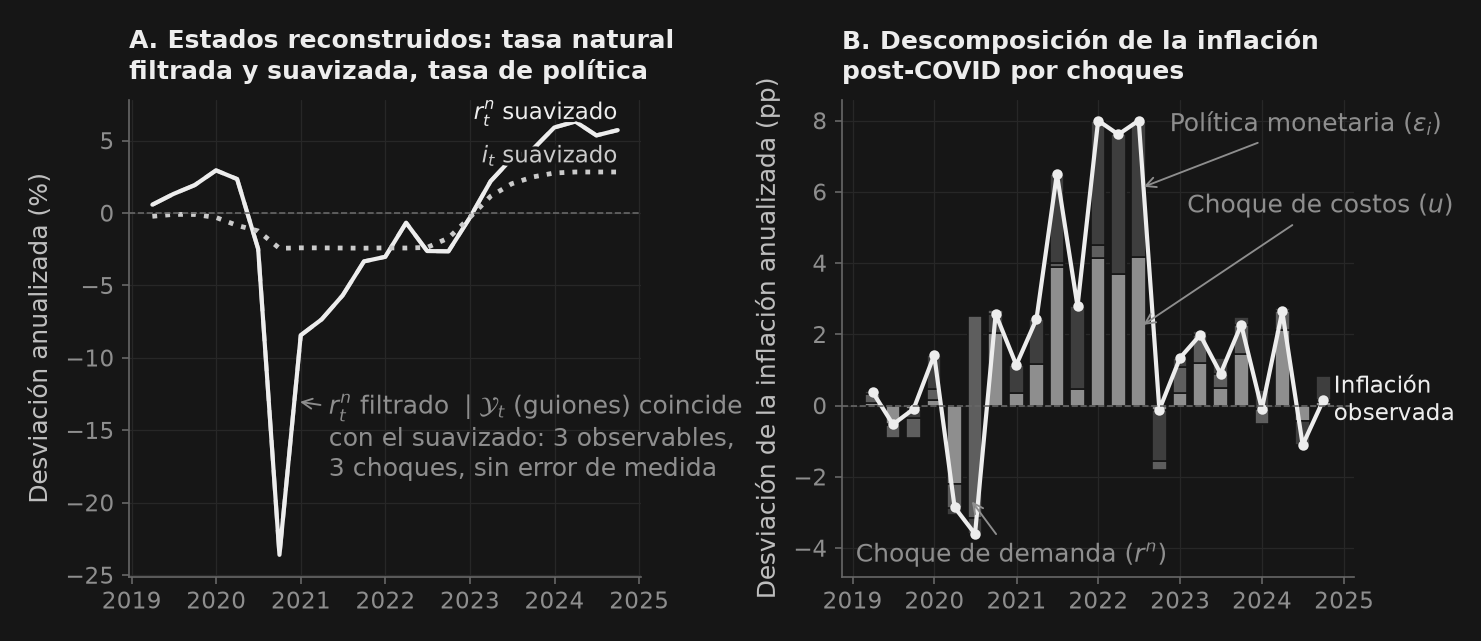


¡Aserciones de descomposición de choques inflacionarios superadas exitosamente!


In [12]:
# ==============================================================================
# Descomposición Histórica de Choques de Inflación Post-COVID (2019-2024)
# ==============================================================================
# 1. Cargar y preparar series empíricas: IPC, PIB Real y Tasa de Fondos Federales
cpi_path = ruta_dato("CPIAUCSL.csv")
gdp_path = ruta_dato("GDPC1.csv")
ff_path  = ruta_dato("FEDFUNDS.csv")

cpi_df = pd.read_csv(cpi_path)
cpi_df["date"] = pd.to_datetime(cpi_df["observation_date"])
cpi_df = cpi_df.set_index("date").sort_index()

gdp_df = pd.read_csv(gdp_path)
gdp_df["date"] = pd.to_datetime(gdp_df["observation_date"])
gdp_df = gdp_df.set_index("date").sort_index()

ff_df = pd.read_csv(ff_path)
ff_df["date"] = pd.to_datetime(ff_df["observation_date"])
ff_df = ff_df.set_index("date").sort_index()

# Desviación de la inflación anualizada trimestral del IPC respecto a la meta de 2%
cpi_q = cpi_df["CPIAUCSL"].resample("QE").last()
infl_dev_ann = 400.0 * np.log(cpi_q / cpi_q.shift(1)) - 2.0  # Puntos porcentuales anualizados

# Desviación de la tasa promedio de fondos federales respecto a la tasa neutral de 2.5%
ff_q = ff_df["FEDFUNDS"].resample("QE").mean()
rate_dev_q = (ff_q - 2.5) / 400.0  # Fracción trimestral

# Brecha de producto: filtro HP sobre el logaritmo del PIB real
gdp_q = gdp_df["GDPC1"].resample("QE").last()
gap_cycle, _ = hp_filter(np.log(gdp_q), lamb=1600.0)

# Construir DataFrame empírico alineado
df_post_covid = pd.DataFrame({
    "y_gap": gap_cycle,
    "pi": infl_dev_ann / 400.0,
    "i": rate_dev_q
}).loc["2019-01-01":"2024-10-01"].dropna()

# 2. Suavizamiento de Kalman y Descomposición Histórica de Choques con el Modelo Neokeynesiano
sm_nk = m_nk.smoother(df_post_covid, varobs=["y_gap", "pi", "i"])
decomp_nk = sm_nk.shock_decomposition()

# Verificar identidad exacta de agregación de la descomposición para todos los observables
for var in ["y_gap", "pi", "i"]:
    comp = decomp_nk.components[var]
    recon = comp[list(m_nk.shocks)].sum(axis=1) + comp["initial_condition"] + comp["steady_state"] + comp["residual"]
    assert np.allclose(recon, comp["actual"], atol=1e-12), f"Fallo en identidad de agregación para {var}"
    assert np.all(np.abs(comp["residual"]) < 1e-11), f"Residuo suavizado no nulo para {var}"

# Descomposición de inflación en puntos porcentuales anualizados
pi_decomp = decomp_nk.components["pi"] * 400.0

print("=" * 76)
print("DESCOMPOSICIÓN HISTÓRICA DE CHOQUES: INFLACIÓN POST-COVID (% Anualizado)")
print("=" * 76)
crisis_table = pi_decomp[["eps_u", "eps_rn", "eps_i", "actual"]].loc["2020-03-31":"2023-03-31"]
print(crisis_table.round(2).to_string())
print("=" * 76)

# 3. Reconstrucción Histórica Bilateral de Estados vs. Estado Filtrado
fig, (ax_st, ax_dec) = _nbstyle.figura(1, 2)

dates = pi_decomp.index
# Reconstrucción de Estados: Tasa Real Natural y Tasa de Política (Filtrada vs. Suavizada)
ax_st.plot(dates, sm_nk.filtered_states["rn"] * 400, **_nbstyle.S2)
ax_st.plot(dates, sm_nk.states["rn"] * 400, **_nbstyle.S1, label="$r^n_t$ suavizado")
ax_st.plot(dates, sm_nk.states["i"] * 400, **_nbstyle.S4, label="$i_t$ suavizado")
# Con tres observables y tres choques el filtro ya identifica el estado: la trayectoria
# filtrada (guiones) queda exactamente debajo de la suavizada
ax_st.annotate("$r^n_t$ filtrado $\\mid \\mathcal{Y}_t$ (guiones) coincide\ncon el suavizado: 3 observables,\n3 choques, sin error de medida",
               xy=(pd.Timestamp("2020-12-10"), -13.0), xytext=(pd.Timestamp("2021-05-01"), -15.5),
               ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_st.axhline(0, color=_nbstyle.SPINE, ls="--", lw=0.8)
ax_st.set_title("A. Estados reconstruidos: tasa natural\nfiltrada y suavizada, tasa de política")
ax_st.set_ylabel("Desviación anualizada (%)")
_nbstyle.etiquetar(ax_st, donde="fin")

# Gráfico de barras apiladas de descomposición de choques para inflación
width = 65  # ancho en días
ax_dec.bar(dates, pi_decomp["eps_u"], width=width, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.8)
ax_dec.bar(dates, pi_decomp["eps_rn"], width=width, bottom=pi_decomp["eps_u"], color=_nbstyle.BARRA_COLORES[2], edgecolor=_nbstyle.FONDO, lw=0.8)
ax_dec.bar(dates, pi_decomp["eps_i"], width=width, bottom=pi_decomp["eps_u"] + pi_decomp["eps_rn"], color=_nbstyle.BARRA_COLORES[3], edgecolor=_nbstyle.FONDO, lw=0.8)
ax_dec.plot(dates, pi_decomp["actual"], **_nbstyle.S1, marker="o", markersize=4, label="Inflación\nobservada")
ax_dec.axhline(0, color=_nbstyle.SPINE, ls="--", lw=0.8)
# Los segmentos apilados se nombran donde cada choque domina la barra
ax_dec.annotate("Política monetaria ($\\varepsilon_i$)", xy=(pd.Timestamp("2022-07-05"), 6.1),
                xytext=(pd.Timestamp("2022-11-15"), 7.9), ha="left", va="center", color=_nbstyle.NOTA,
                arrowprops=_nbstyle.FLECHA)
ax_dec.annotate("Choque de costos ($u$)", xy=(pd.Timestamp("2022-07-05"), 2.2),
                xytext=(pd.Timestamp("2023-02-01"), 5.6), ha="left", va="center", color=_nbstyle.NOTA,
                arrowprops=_nbstyle.FLECHA)
ax_dec.annotate("Choque de demanda ($r^n$)", xy=(pd.Timestamp("2020-06-05"), -2.6),
                xytext=(pd.Timestamp("2019-01-15"), -4.2), ha="left", va="center", color=_nbstyle.NOTA,
                arrowprops=_nbstyle.FLECHA)
ax_dec.set_ylim(bottom=-4.8)
ax_dec.set_title("B. Descomposición de la inflación\npost-COVID por choques")
ax_dec.set_ylabel("Desviación de la inflación anualizada (pp)")
_nbstyle.etiquetar(ax_dec, donde="fin")

plt.show()

# Aserciones de verificación
peak_cost_push = float(pi_decomp.loc["2021-06-01":"2022-06-30", "eps_u"].max())
lockdown_demand = float(pi_decomp.loc["2020-06-30", "eps_rn"])

assert peak_cost_push > 3.0, f"Los choques de costos deben explicar >3pp de la inflación máxima en 2021-22: {peak_cost_push:.2f}"
assert lockdown_demand < -3.0, f"El choque de demanda en el confinamiento debe ser < -3pp: {lockdown_demand:.2f}"
print("\n¡Aserciones de descomposición de choques inflacionarios superadas exitosamente!")


## Pronóstico Dinámico DSGE: Proyecciones Prospectivas y Gráficos de Abanico Consistentes

Una función primordial de los modelos DSGE estructurales en los bancos centrales (e.g., Reserva Federal, BCE, Banco de Inglaterra, Banco de México) es la **proyección condicional de escenarios y la cuantificación rigurosa de la incertidumbre**.

A partir del estado filtrado terminal $\hat{x}_T = \mathbb{E}[x_T \mid \mathcal{Y}_T]$ y su covarianza de error de estimación $P_T = \mathbb{E}[(x_T - \hat{x}_T)(x_T - \hat{x}_T)' \mid \mathcal{Y}_T]$, `puremacro.dsge.LinearModel.forecast(horizon=H, data=data, ci=0.90)` calcula las esperanzas prospectivas bajo expectativas racionales:
$$\mathbb{E}_T[\mathcal{Y}_{T+h}] = d + Z A^h \hat{x}_T$$
junto con la covarianza de incertidumbre por choques futuros:
$$\mathbb{V}_T[\mathcal{Y}_{T+h}] = Z P_{T+h \mid T} Z' + H$$
donde $P_{T+h \mid T} = A P_{T+h-1 \mid T} A' + B Q B'$.

A continuación, proyectamos a un horizonte de $H=12$ trimestres condicionado en el estado terminal de 2024Q3/Q4, generando gráficos de abanico para la inflación $\pi_t$ y la brecha de producto $y_t^{\text{gap}}$ con bandas de confianza al $90\%$ consistentes con el modelo.

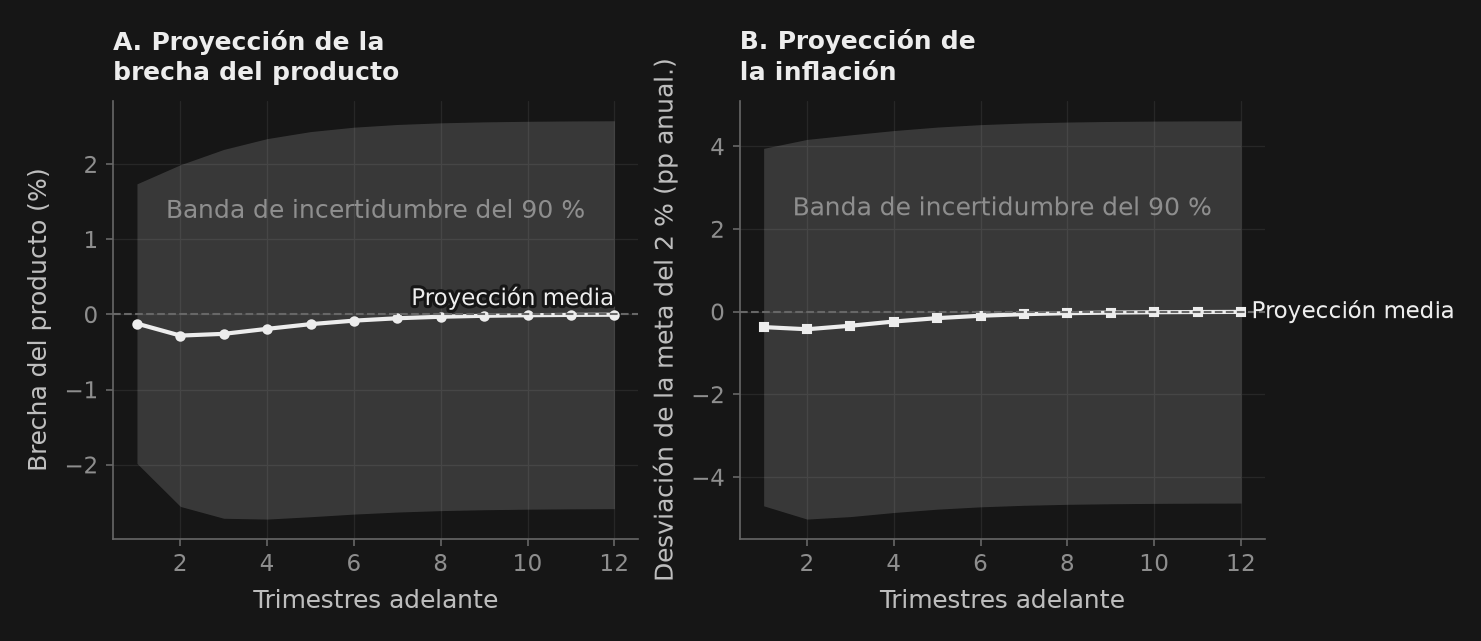

RESUMEN DE PRONÓSTICO DINÁMICO DSGE (H=12 Trimestres Adelante)
Trimestre  Brecha Media (%)   Brecha IC 90%  Inflación Media (% an) Inflación IC 90%
      h=1         -0.121805 [-1.98%, 1.74%]               -0.370964  [-4.69%, 3.95%]
      h=2         -0.281339 [-2.56%, 1.99%]               -0.423230  [-5.02%, 4.17%]
      h=3         -0.258043 [-2.71%, 2.20%]               -0.338206  [-4.96%, 4.28%]
      h=4         -0.191518 [-2.72%, 2.34%]               -0.236507  [-4.86%, 4.38%]
      h=5         -0.129036 [-2.69%, 2.43%]               -0.154144  [-4.78%, 4.47%]
      h=6         -0.082237 [-2.66%, 2.49%]               -0.096182  [-4.72%, 4.53%]
      h=7         -0.050553 [-2.63%, 2.53%]               -0.058266  [-4.68%, 4.57%]
      h=8         -0.030300 [-2.61%, 2.55%]               -0.034551  [-4.66%, 4.59%]
      h=9         -0.017825 [-2.60%, 2.56%]               -0.020160  [-4.64%, 4.60%]
     h=10         -0.010337 [-2.59%, 2.57%]               -0.011616  [-4.64%, 4.61%]
  

In [13]:
# ==============================================================================
# Pronóstico Dinámico Consistente con el Modelo y Gráficos de Abanico
# ==============================================================================
# Pronóstico dinámico condicionado en el estado terminal histórico
fc_nk = m_nk.forecast(horizon=12, data=df_post_covid, varobs=["y_gap", "pi", "i"], ci=0.90)

# Reescalar objetos de pronóstico a unidades estándar de presentación macroeconómica
h_vec = np.arange(1, 13)
pi_mean_ann = fc_nk.mean["pi"].values * 400.0
pi_low_ann  = fc_nk.lower["pi"].values * 400.0
pi_upp_ann  = fc_nk.upper["pi"].values * 400.0

ygap_mean_pct = fc_nk.mean["y_gap"].values * 100.0
ygap_low_pct  = fc_nk.lower["y_gap"].values * 100.0
ygap_upp_pct  = fc_nk.upper["y_gap"].values * 100.0

fig, (ax_ygap, ax_pi) = _nbstyle.figura(1, 2)

# Panel 1: Proyección de la Brecha de Producto
ax_ygap.plot(h_vec, ygap_mean_pct, **_nbstyle.S1, marker="o", markersize=4, label="Proyección media")
ax_ygap.fill_between(h_vec, ygap_low_pct, ygap_upp_pct, color=_nbstyle.BANDA, lw=0)
ax_ygap.axhline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_ygap.annotate("Banda de incertidumbre del 90 %", xy=(6.5, 0.55 * ygap_upp_pct[5]),
                 ha="center", va="center", color=_nbstyle.NOTA)
ax_ygap.set_title("A. Proyección de la\nbrecha del producto")
ax_ygap.set_xlabel("Trimestres adelante")
ax_ygap.set_ylabel("Brecha del producto (%)")
_nbstyle.etiquetar(ax_ygap, donde="fin")

# Panel 2: Proyección de Inflación
ax_pi.plot(h_vec, pi_mean_ann, **_nbstyle.S1, marker="s", markersize=4, label="Proyección media")
ax_pi.fill_between(h_vec, pi_low_ann, pi_upp_ann, color=_nbstyle.BANDA, lw=0)
ax_pi.axhline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_pi.annotate("Banda de incertidumbre del 90 %", xy=(6.5, 0.55 * pi_upp_ann[5]),
               ha="center", va="center", color=_nbstyle.NOTA)
ax_pi.set_title("B. Proyección de\nla inflación")
ax_pi.set_xlabel("Trimestres adelante")
ax_pi.set_ylabel("Desviación de la meta del 2 % (pp anual.)")
_nbstyle.etiquetar(ax_pi, donde="fin")

plt.show()

print("=" * 76)
print("RESUMEN DE PRONÓSTICO DINÁMICO DSGE (H=12 Trimestres Adelante)")
print("=" * 76)
fc_summary_df = pd.DataFrame({
    "Trimestre": [f"h={h}" for h in h_vec],
    "Brecha Media (%)": ygap_mean_pct,
    "Brecha IC 90%": [f"[{l:.2f}%, {u:.2f}%]" for l, u in zip(ygap_low_pct, ygap_upp_pct)],
    "Inflación Media (% an)": pi_mean_ann,
    "Inflación IC 90%": [f"[{l:.2f}%, {u:.2f}%]" for l, u in zip(pi_low_ann, pi_upp_ann)],
})
print(fc_summary_df.to_string(index=False))
print("=" * 76)

# Aserciones de verificación
assert (fc_nk.lower["pi"] < fc_nk.mean["pi"]).all(), "La banda inferior de inflación debe estar bajo la media."
assert (fc_nk.upper["pi"] > fc_nk.mean["pi"]).all(), "La banda superior de inflación debe estar sobre la media."
assert (fc_nk.lower["y_gap"] < fc_nk.mean["y_gap"]).all(), "La banda inferior de la brecha debe estar bajo la media."
assert (fc_nk.upper["y_gap"] > fc_nk.mean["y_gap"]).all(), "La banda superior de la brecha debe estar sobre la media."
assert abs(fc_nk.mean.iloc[-1]["pi"]) < abs(fc_nk.mean.iloc[0]["pi"]), "La inflación debe converger hacia la meta sobre el horizonte."
print("\n¡Aserciones de proyección dinámica DSGE superadas exitosamente!")


## Simulación DSGE No Lineal: Algoritmo Extended Path de Fair y Taylor (1983)

Los métodos estándar de perturbación linealizan las condiciones de equilibrio alrededor del estado estacionario determinista. Aunque computacionalmente instantáneas, las aproximaciones de primer orden imponen **equivalencia de certidumbre local** y jacobianos constantes. Cuando los choques macroeconómicos son de gran magnitud —como el episodio inflacionario post-COVID— o cuando la economía enfrenta **reglas de política asimétricas y restricciones que se activan ocasionalmente** (como pisos a la tasa de interés), las aproximaciones lineales pueden generar sesgos significativos o violar límites estructurales.

El método de **Extended Path** (Fair y Taylor 1983), implementado de forma nativa en `puremacro.dsge.extended_path`, simula modelos dinámicos no lineales sin perturbación y sin la maldición de la dimensionalidad de Bellman:
1. En cada período de simulación $t \in \{0, \dots, T-1\}$, la economía parte del estado predeterminado histórico $y_{t-1}$ y recibe la innovación estructural contemporánea $u_t$.
2. Las innovaciones estocásticas futuras se reemplazan por su esperanza matemática condicional: $\mathbb{E}_t[u_{t+s}] = 0$ para todo horizonte de anticipación $s \ge 1$.
3. El problema de frontera determinista resultante a lo largo del horizonte $T_H$ ($y_{t+T_H \mid t} = y_{ss}$) se formula como un sistema no lineal apilado y se resuelve mediante el motor sparse SuperLU Newton-Raphson de `puremacro.dsge.solve_perfect_foresight`.
4. Se extrae el estado contemporáneo $y_t = y_{t \mid t}$, se actualiza el estado histórico ($y_{t-1} \leftarrow y_t$) y se realiza un arranque en caliente (*warm start*) para la fecha $t+1$.

### Propiedades Clave e Invariantes:
- **Invarianza Lineal**: Para modelos DSGE lineales, `extended_path` coincide con la simulación lineal de espacio de estados `m.simulate()` a precisión de máquina (desviación absoluta máxima $< 10^{-10}$).
- **Problemas de Complementariedad Mixta (MCP)**: Aplica restricciones de desigualdad (como un piso asimétrico a la tasa de interés nominal $i_t \ge i_{\min}$) mediante operadores semisuaver de complementariedad.

EXTENDED PATH DE FAIR-TAYLOR: VERIFICACIÓN DE INVARIANZA LINEAL
Variable endógena 'y_gap ': max |EP - Lineal| = 3.82e-17
Variable endógena 'pi    ': max |EP - Lineal| = 1.91e-17
Variable endógena 'i     ': max |EP - Lineal| = 1.91e-17
Variable endógena 'rn    ': max |EP - Lineal| = 4.34e-19
Variable endógena 'u     ': max |EP - Lineal| = 1.73e-18


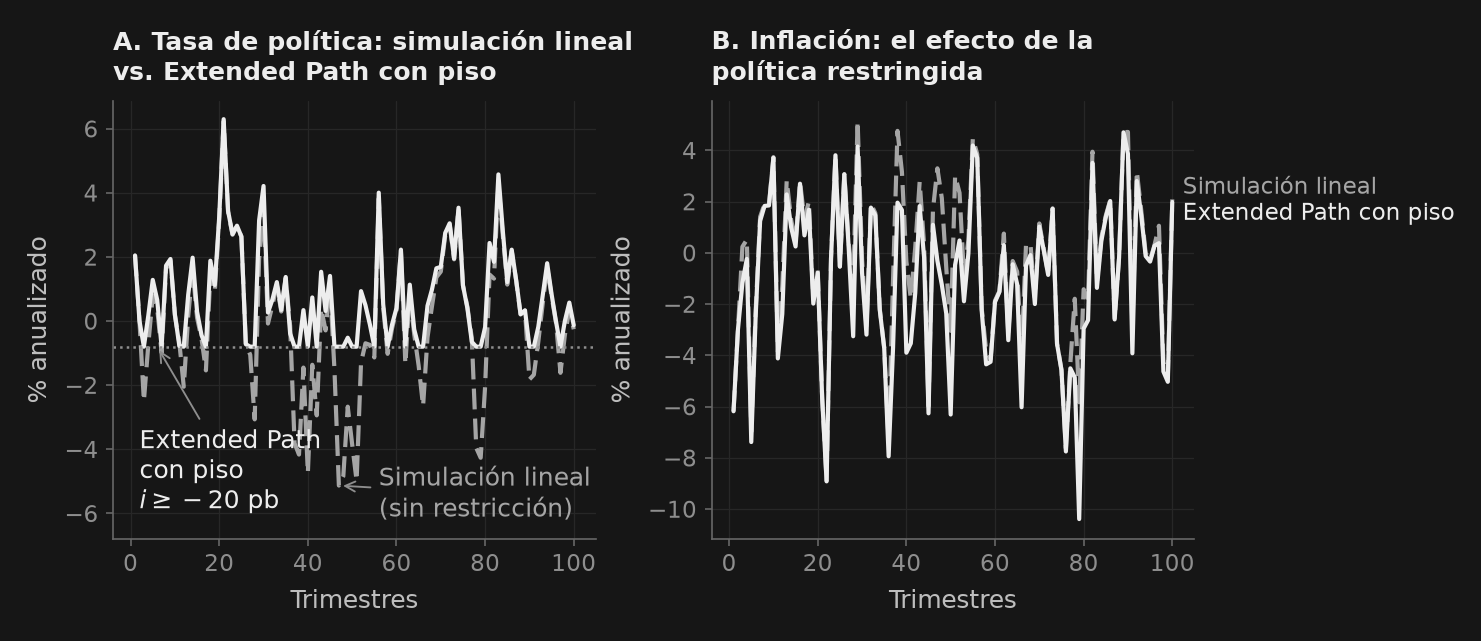


EXTENDED PATH SIMULATION RESULT (Fair-Taylor 1983)
Convergence status  : CONVERGED
Simulation periods  : 100
Forward horizon T_H : 80
Total iterations    : 574 (mean: 5.74, max: 9)
Residual norm       : 3.6178e-11
Terminal error      : 1.7491e-23
Endogenous vars (5) : y_gap, pi, i, rn, u
Structural shocks (3) : eps_i, eps_rn, eps_u
------------------------------------------------------------------------
TRAJECTORY SUMMARY (t=1..T):
           mean       std       min       max   initial  terminal
y_gap -0.008964  0.014403 -0.062057  0.018682 -0.001818  0.000875
pi    -0.002840  0.007919 -0.025976  0.011759 -0.015457  0.004959
i      0.001869  0.003755 -0.002000  0.015747  0.005119 -0.000331
rn    -0.001509  0.005582 -0.016586  0.011549  0.007357  0.000022
u     -0.000368  0.005273 -0.014183  0.011448 -0.008537  0.002896


In [14]:
# ==============================================================================
# Simulación Estocástica No Lineal mediante Extended Path (Fair y Taylor 1983)
# ==============================================================================
from puremacro.dsge import extended_path

# 1. Configuración de simulación estocástica con innovaciones estructurales idénticas
sim_periods = 100
sim_horizon = 80
rng_seed = 20260909
sim_shocks = np.random.default_rng(rng_seed).normal(0.0, 0.005, size=(sim_periods, len(m_nk.shocks)))

# Ejecutar simulación Extended Path de Fair-Taylor
ep_nk = extended_path(
    m_nk,
    periods=sim_periods,
    horizon=sim_horizon,
    shocks=sim_shocks,
    tol=1e-8,
)

# Ejecutar simulación lineal estándar en espacio de estados
sim_linear = m_nk.simulate(periods=sim_periods, shocks=sim_shocks)

# 2. Verificar Invarianza Lineal Exacta a Precisión de Máquina
max_devs = {}
for var in m_nk.variables:
    dev = np.max(np.abs(ep_nk.path[var].values - sim_linear[var].values))
    max_devs[var] = dev

print("=" * 76)
print("EXTENDED PATH DE FAIR-TAYLOR: VERIFICACIÓN DE INVARIANZA LINEAL")
print("=" * 76)
for var, dev in max_devs.items():
    print(f"Variable endógena '{var:6s}': max |EP - Lineal| = {dev:.2e}")
print("=" * 76)

assert ep_nk.converged is True, "El solucionador Newton-Raphson de Extended Path debe converger."
assert all(d < 1e-10 for d in max_devs.values()), (
    "Extended Path debe reproducir la simulación lineal a precisión de máquina."
)

# 3. Simulación No Lineal con Piso de Política mediante Complementariedad Mixta (MCP)
# El banco central impone una cota inferior asimétrica: i_t >= -0.0020 (-20 pb)
ep_mcp = extended_path(
    m_nk,
    periods=sim_periods,
    horizon=sim_horizon,
    shocks=sim_shocks,
    mcp=True,
    mcp_bounds={"i": (-0.002, None)},
    tol=1e-8,
)

assert ep_mcp.converged is True, "Extended Path con cotas MCP debe converger."
assert (ep_mcp.path["i"] >= -0.002 - 1e-10).all(), "El piso de política monetaria debe respetarse estrictamente."

# 4. Visualización Comparativa de Trayectorias
fig, (ax_ep_i, ax_ep_pi) = _nbstyle.figura(1, 2)

t_axis = np.arange(1, sim_periods + 1)

# Comparación de Tasa de Política Nominal
ax_ep_i.plot(t_axis, sim_linear["i"] * 400, **_nbstyle.S2, label="Simulación lineal\n(sin restricción)")
ax_ep_i.plot(t_axis, ep_mcp.path["i"] * 400, **_nbstyle.S1, label="Extended Path\ncon piso")
ax_ep_i.axhline(-0.002 * 400, color=_nbstyle.NOTA, ls=":", lw=1.2)
ax_ep_i.set_title("A. Tasa de política: simulación lineal\nvs. Extended Path con piso")
ax_ep_i.set_xlabel("Trimestres")
ax_ep_i.set_ylabel("% anualizado")
# Las dos series solo se separan cuando el piso muerde: cada una se nombra ahí, desde el
# espacio libre bajo la trayectoria (la lineal en su valle más hondo, la otra sobre el piso)
ax_ep_i.set_ylim(bottom=-6.8)
lin_i, mcp_i = ax_ep_i.get_lines()[:2]
t_min = int(np.argmin(sim_linear["i"].values)) + 1
ax_ep_i.annotate(lin_i.get_label(), xy=(t_min, float(sim_linear["i"].min() * 400)),
                 xytext=(t_min + 9, -5.4), ha="left", va="center", color=lin_i.get_color(),
                 arrowprops=_nbstyle.FLECHA)
ax_ep_i.annotate(mcp_i.get_label() + "\n$i \\geq -20$ pb", xy=(6.0, -0.002 * 400), xytext=(2.0, -4.7),
                 ha="left", va="center", color=mcp_i.get_color(), arrowprops=_nbstyle.FLECHA)

# Comparación de Trayectoria de Inflación
ax_ep_pi.plot(t_axis, sim_linear["pi"] * 400, **_nbstyle.S2, label="Simulación lineal")
ax_ep_pi.plot(t_axis, ep_mcp.path["pi"] * 400, **_nbstyle.S1, label="Extended Path con piso")
ax_ep_pi.set_title("B. Inflación: el efecto de la\npolítica restringida")
ax_ep_pi.set_xlabel("Trimestres")
ax_ep_pi.set_ylabel("% anualizado")
_nbstyle.etiquetar(ax_ep_pi, donde="fin")

plt.show()

# 5. Informe de Resumen de Publicación
print("\n" + ep_mcp.summary())
